# FINN3021 — Ex-ante Equity Screen

**As-of date:** 9 March 2026 (strict point-in-time — no data released after this date is admitted).

**Universe:** Global ex-US large/mid cap (DM ex-US + EM, single pool), ex-Financials, ex-Real Estate.

**Tier 1 hard knockouts:** FCF > 0 in each of last 5 FYs · net debt / EBITDA < 4× · sector filter.

**Tier 2 composite:** 0.50·Piotroski + 0.30·ROIC(5y avg) + 0.20·FCF growth(5y CAGR), min-max scaled across the ex-US pool.

**Ranking:** 5-year mean of historical FCF_t / EV_t multiples, within top-quintile composite.

**Output:** top `N_PORTFOLIO` ex-US names. Further value-trap risk controls to be layered in.

---

This notebook is fully self-contained — config, helpers, and pipeline all live here. Run top to bottom.

## 0a · Install dependencies (run once)

Run this cell **once per kernel environment**, then skip on future runs. `%pip` installs into whatever kernel VS Code has selected — no env mismatch.

In [1]:
%pip install --quiet wrds pandas numpy matplotlib seaborn python-dotenv pyarrow yfinance requests tabulate

Note: you may need to restart the kernel to use updated packages.


## 0 · Imports

In [2]:
import os, pathlib, json
from datetime import date
from dataclasses import dataclass, field
from typing import Any, Iterable
from pandas.tseries.offsets import DateOffset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

try:
    from dotenv import load_dotenv
except ImportError:
    def load_dotenv(*a, **k): pass

ROOT = pathlib.Path().resolve().parent
load_dotenv(ROOT / ".env")
CACHE = ROOT / "data" / "cache"; CACHE.mkdir(parents=True, exist_ok=True)
OUT = ROOT / "data" / "outputs"; OUT.mkdir(parents=True, exist_ok=True)

def stamp(): return pd.Timestamp.now(tz="UTC").isoformat(timespec="seconds")
print(f"run at: {stamp()}")

run at: 2026-04-16T19:47:22+00:00


## 1 · Committed screen parameters
Change values here — never edit inline below. If you change them you must explain why in the report.

In [3]:
SCREEN_ASOF = date(2026, 3, 9)

# MSCI DM ex-US (ISO-2)
DM_EX_US = {"GB","JP","CA","AU","DE","FR","CH","NL","SE","ES","IT","DK","HK","SG","BE","NO","FI","IL","IE","AT","PT","NZ"}
# MSCI EM (ISO-2)
EM      = {"CN","IN","KR","TW","BR","ZA","MX","SA","AE","QA","KW","TH","MY","ID","PH","PL","HU","CZ","GR","TR","CL","PE","CO","EG"}
UNIVERSE = DM_EX_US | EM

EXCLUDED_GSECTOR = {"40", "60"}  # GICS Financials, Real Estate

# Tier 1
LEVERAGE_MAX        = 4.0
FCF_HISTORY_YEARS   = 5
N_YEARS_FUNDA       = 5

# Tier 2 composite weights (sum to 1.0)
W_PIOTROSKI    = 0.50
W_ROIC_5Y      = 0.30
W_FCF_GROWTH   = 0.20

QUINTILE_CUT   = 0.50      # top 50% of composite across ex-US pool
N_PORTFOLIO    = 500       # pre-selection ranked pool (wide net)

# === Size / liquidity gates (institutional-scale) ===
# Tiered mcap floor: large-cap in DM, mid-cap in EM (keeps EM breadth without microcaps).
MCAP_MIN_USD_DM    = 2_000_000_000   # DM:  >= $2bn
MCAP_MIN_USD_EM    = 1_000_000_000   # EM:  >= $1bn
# ADV hard floor — small fund size means volume rarely binds, so floor is modest
# and the soft L-flag (ADV<$1m) does most of the real liquidity work at display time.
ADV_MIN_USD        = 100_000         # median 60d dollar volume floor (hard gate)
ADV_FLAG_THRESHOLD = 1_000_000       # soft 'L' flag if ADV below this

# === Absolute quality gates (mirror the valuation floor) ===
ROIC_5Y_MIN        = 0.10            # 5y mean ROIC >= 12% (above reasonable WACC)
ROIC_10Y_MIN       = 0.05            # 10y min ROIC >= 8% (never destroyed capital)
FCF_MARGIN_5Y_MIN  = 0.05            # 5y mean FCF / sales >= 8%
PIOTROSKI_MIN      = 5               # F-score floor (1-9 scale)

# === Valuation gate — "not expensive", not a ranking input ===
EY_MIN             = 0.05            # earnings yield > 5%  OR ...
FCF_EV_MIN         = 0.05            # FCF/EV > 5%
# High-ROIC escape hatch: proven compounders can clear the valuation gate at
# a richer multiple (PE ~33x) if ROIC is 50% above the quality-gate floor.
ROIC_ESCAPE_MIN    = 0.15            # ROIC 5y avg >= 15% (vs 10% quality floor)
EY_ESCAPE_MIN      = 0.03            # AND earnings yield > 3% (PE up to ~33x)
FCF_EV_FLAG_CEIL   = 0.15            # FCF/EV > 15% -> EV-collapse trap flag (not a gate)
SHARES_DILUTION_FLAG = 0.05          # 5y shares growth > +5% -> dilution flag

# Final portfolio size + concentration caps (country AND sector).
# Iterative fill: walk names in rank order, skip any that would breach either cap.
N_FINAL             = 20             # final portfolio size
COUNTRY_MAX_PCT     = 0.25           # no single country > 25% of final portfolio
SECTOR_MAX_PCT      = 0.25           # no single GICS sector > 25% of final portfolio


# EV sanity gate — exclude firm-years where net cash dominates
MIN_EV_MCAP_RATIO   = 0.30

# Winsorize per-year FCF/EV before averaging (caps one-off cash explosions)
# and prevents data-anomaly names dominating the ranking.
FCF_EV_CAP          = 0.60    # per-year cap on FCF/EV (any value above is clipped to this)

# Value-trap flags — advisory columns, NOT exclusions
SALES_CAGR_MIN      = -0.02   # flag if 5y sales CAGR < -2% (shrinking top line)
ROIC_RATIO_MIN      = 0.70    # flag if latest-FY ROIC < 70% of 5y mean (deteriorating returns)
ACCRUALS_MAX        = 0.05    # flag if (NI-CFO)/avg assets > +5% (earnings not backed by cash)

# Cyclical industry flag — advisory, reported alongside S/R/A. GICS 2-digit:
# 10 = Energy (oil, gas, coal), 15 = Materials (mining, chemicals, paper).
# 5y FCF persistence in these sectors partly reflects commodity cycles, not
# operational moat, so treat FCF/EV with scrutiny.
CYCLICAL_GSECTORS   = {"10", "15"}

# Chinese private-sector whitelist. Names matching any substring here survive
# the China SOE exclusion. Extend as needed (e.g. "BYD", "TENCENT", "MEITUAN").
CN_WHITELIST_PATTERNS = {"BYD"}

# Non-recurring flag — fires when the metric history looks too good to be
# sustainable: either trailing ROIC is a multiple of the 5y mean (one-off
# surge) or FCF CAGR is explosive (low base, restructuring pop, accounting
# one-off). Advisory only.
FCF_CAGR_MAX_NORMAL = 1.00    # flag if 5y FCF CAGR > 100%
ROIC_SURGE_MULT     = 2.00    # flag if latest-FY ROIC > 2x 5y mean

# Point-in-time: conservative filing-lag proxy when rdq is missing

# QA sanity thresholds
QA_MAX_ROIC = 3.0;  QA_MIN_ROIC = -3.0
QA_MAX_LEVERAGE = 50.0

print(f"screen as-of: {SCREEN_ASOF}")
print(f"universe: {len(DM_EX_US) + len(EM)} ex-US countries ({len(DM_EX_US)} DM + {len(EM)} EM, pooled)")

# === Structural under-pricing tags & scoring ===
# Steady-state tags identifying names under-bid by mandate-constrained capital.
# Not event-driven — no forced selling / deletions / momentum signals here.
STRUCT_PURE_WEIGHT   = 0.20          # per-tag boost for "pure" structural tags
STRUCT_MIXED_WEIGHT  = 0.10          # per-tag boost for "mixed" (country/flow) tags
STRUCT_COVERAGE_MCAP_FLOOR = 1_500_000_000   # fallback: mcap < $1.5bn counts as low coverage
# GICS sub-industries (8-digit) flagged as ESG-excluded
STRUCT_ESG_DEEP      = {30203010, 25201010, 25301010, 10102050}     # tobacco, casinos, gambling, coal
STRUCT_ESG_PARTIAL   = {20101010, 30201020, 30201030, 10102010, 10102020}  # aero&def, distillers, brewers, int O&G, E&P
# Country sets (ISO-2)
STRUCT_DM_COUNTRIES  = {"JP","GB","DE","FR","CH","AU","CA","SE","DK","NO","FI","NL","BE",
                        "IT","ES","IE","HK","SG","IL","NZ","AT","PT"}
STRUCT_ORPHAN_COUNTRY = {"SA","VN","PK","EG","GR","HU","CZ","PE","CL","CO","PH",
                         "AE","QA","KW","TR","MA"}
STRUCT_RETAIL_DOMINATED = {"KR","TW","IN","TR","TH","VN"}
# Benchmark-orphan mcap band (DM and EM)
STRUCT_BMK_DM_LO, STRUCT_BMK_DM_HI = 500_000_000, 3_000_000_000
STRUCT_BMK_EM_LO, STRUCT_BMK_EM_HI = 300_000_000, 2_000_000_000


screen as-of: 2026-03-09
universe: 46 ex-US countries (22 DM + 24 EM, pooled)


## 2 · WRDS connection (Postgres preferred; REST fallback)

**Postgres** — uses the standard `wrds` Python package. First run prompts for your WRDS password and writes `~/.pgpass` so subsequent runs are passwordless.

**REST fallback** — used only if Postgres fails. Set `WRDS_API_TOKEN` in `.env`.

In [4]:
WRDS_USERNAME = os.getenv("WRDS_USERNAME")
WRDS_API_TOKEN = os.getenv("WRDS_API_TOKEN")
REST_BASE = "https://wrds-api.wharton.upenn.edu/data"

db = None
try:
    import wrds
    db = wrds.Connection(wrds_username=WRDS_USERNAME)
    print(f"[wrds] Postgres connected as {WRDS_USERNAME}")
except Exception as e:
    print(f"[wrds] Postgres unavailable ({e}); REST fallback only")

def sql_cached(query: str, cache_name: str, force: bool = False) -> pd.DataFrame:
    path = CACHE / f"{cache_name}.parquet"
    if path.exists() and not force:
        print(f"[cache hit] {cache_name}")
        return pd.read_parquet(path)
    if db is None:
        raise RuntimeError("No Postgres connection. Fix wrds auth before proceeding.")
    print(f"[sql pull] {cache_name} ...")
    df = db.raw_sql(query)
    df.to_parquet(path, index=False)
    print(f"           {len(df):,} rows saved → cache/{cache_name}.parquet")
    return df

def rest_get(endpoint, params=None, cache_name=None, force=False):
    if cache_name:
        path = CACHE / f"{cache_name}.parquet"
        if path.exists() and not force:
            print(f"[cache hit] {cache_name}")
            return pd.read_parquet(path)
    if not WRDS_API_TOKEN:
        raise RuntimeError("WRDS_API_TOKEN missing in .env")
    url = f"{REST_BASE}/{endpoint.strip(chr(47))}/"
    headers = {"Accept": "application/json", "Authorization": f"Token {WRDS_API_TOKEN}"}
    rows, next_url, call_params = [], url, params
    while next_url:
        r = requests.get(next_url, headers=headers, params=call_params, timeout=60)
        r.raise_for_status()
        payload = r.json()
        if isinstance(payload, dict) and "results" in payload:
            rows.extend(payload["results"]); next_url = payload.get("next"); call_params = None
        else:
            rows.extend(payload if isinstance(payload, list) else [payload]); next_url = None
    df = pd.DataFrame(rows)
    if cache_name: df.to_parquet(CACHE / f"{cache_name}.parquet", index=False)
    return df


Loading library list...
Done
[wrds] Postgres connected as conrad_green


## 3 · QA helpers
Ran at every pipeline stage to catch silent errors.

In [5]:
def qa_report(df: pd.DataFrame, stage: str, firm_col="gvkey",
              country_col="fic", sector_col="gsector", check_cols=None) -> None:
    print(f"\n=== {stage} ===")
    print(f"  rows:  {len(df):,}")
    if firm_col in df.columns: print(f"  firms: {df[firm_col].nunique():,}")
    if country_col and country_col in df.columns:
        top = df[country_col].value_counts().head(8)
        print("  top countries: " + ", ".join(f"{k}={v}" for k, v in top.items()))
    if sector_col and sector_col in df.columns:
        secs = df[sector_col].astype(str).value_counts()
        print("  sectors: " + ", ".join(f"{k}={v}" for k, v in sorted(secs.items())))
    if check_cols:
        miss = {c: df[c].isna().mean() for c in check_cols if c in df.columns}
        bad = {k: v for k, v in miss.items() if v > 0}
        if bad: print("  missing: " + ", ".join(f"{k}={v:.1%}" for k, v in bad.items()))
    if "roic" in df.columns:
        absurd = ((df["roic"] > QA_MAX_ROIC) | (df["roic"] < QA_MIN_ROIC)).sum()
        if absurd: print(f"  \u26a0 {absurd} rows with ROIC outside [{QA_MIN_ROIC},{QA_MAX_ROIC}]")
    if "net_debt_ebitda" in df.columns:
        absurd = (df["net_debt_ebitda"].abs() > QA_MAX_LEVERAGE).sum()
        if absurd: print(f"  \u26a0 {absurd} rows with |net_debt/EBITDA| > {QA_MAX_LEVERAGE}")

def assert_point_in_time(df: pd.DataFrame, asof: Any, date_col: str = "effective_date") -> None:
    asof_ts = pd.Timestamp(asof)
    latest = pd.to_datetime(df[date_col]).max()
    if latest > asof_ts:
        leaks = (pd.to_datetime(df[date_col]) > asof_ts).sum()
        raise AssertionError(f"POINT-IN-TIME VIOLATION: {leaks} rows with {date_col} > {asof_ts.date()}")
    print(f"[point-in-time OK] latest {date_col} = {latest.date()} \u2264 {asof_ts.date()}")

def freshness_by_country(df: pd.DataFrame, date_col="datadate") -> pd.DataFrame:
    return df.groupby("fic")[date_col].max().sort_values().to_frame("latest_datadate")

## 4 · Universe — `comp.g_company`
Static firm info; filter to DM ex-US + EM, drop Financials and Real Estate.

In [6]:
# comp.g_company uses ISO-3 country codes; UNIVERSE is ISO-2
ISO2_TO_ISO3 = {
    "AE":"ARE","AT":"AUT","AU":"AUS","BE":"BEL","BR":"BRA","CA":"CAN","CH":"CHE",
    "CL":"CHL","CN":"CHN","CO":"COL","CZ":"CZE","DE":"DEU","DK":"DNK","EG":"EGY",
    "ES":"ESP","FI":"FIN","FR":"FRA","GB":"GBR","GR":"GRC","HK":"HKG","HU":"HUN",
    "ID":"IDN","IE":"IRL","IL":"ISR","IN":"IND","IT":"ITA","JP":"JPN","KR":"KOR",
    "KW":"KWT","MX":"MEX","MY":"MYS","NL":"NLD","NO":"NOR","NZ":"NZL","PE":"PER",
    "PH":"PHL","PL":"POL","PT":"PRT","QA":"QAT","SA":"SAU","SE":"SWE","SG":"SGP",
    "TH":"THA","TR":"TUR","TW":"TWN","ZA":"ZAF",
}
UNIVERSE_ISO3 = {ISO2_TO_ISO3[c] for c in UNIVERSE}
iso_sql = ",".join(f"'{c}'" for c in sorted(UNIVERSE_ISO3))

q_company = f"""
    SELECT gvkey, conm AS company_name, fic, gsector, ggroup, gind, gsubind,
           loc, ipodate
    FROM comp.g_company
    WHERE fic IN ({iso_sql})
"""
company = sql_cached(q_company, "g_company_universe")
company = company[~company["gsector"].astype(str).isin(EXCLUDED_GSECTOR)].copy()
qa_report(company, "Universe (post-sector-filter)", check_cols=["gsector", "fic"])


[cache hit] g_company_universe

=== Universe (post-sector-filter) ===
  rows:  60,637
  firms: 60,637
  top countries: CHN=6997, IND=6216, JPN=6174, GBR=5328, KOR=4966, AUS=4076, TWN=2953, IRL=1966
  sectors: 10=1341, 15=6397, 20=10570, 25=8097, 30=3555, 35=3907, 45=7910, 50=2137, 55=1028, <NA>=15695
  missing: gsector=25.9%


## 5 · Fundamentals — `comp.g_funda`

8-year window (2018-2026) — more than needed for 5y history, so we have headroom if the very latest FY hasn't filed yet.

**Point-in-time rule:** `effective_date = datadate + 4 months`; admit only if `≤ 2026-03-09`.

In [7]:
excl_sector_sql = ",".join(f"'{s}'" for s in EXCLUDED_GSECTOR)

q_funda = f"""
    SELECT f.gvkey, f.datadate, f.fyear,
           f.oancf, f.capx, f.dp, f.oibdp, f.ebit,
           f.dlc, f.dltt, f.che,
           f.nicon, f.at, f.act, f.lct, f.cshoi, f.sale, f.cogs,
           f.ceq, f.txt, f.pi, f.curcd,
           f.dvt, f.xint, f.re, f.lt
    FROM comp.g_funda f
    JOIN comp.g_company c USING (gvkey)
    WHERE c.fic IN ({iso_sql})
      AND NOT c.gsector::text IN ({excl_sector_sql})
      AND f.indfmt = 'INDL'
      AND f.datafmt = 'HIST_STD'
      AND f.consol  = 'C'
      AND f.popsrc  = 'I'
      AND f.datadate BETWEEN '2016-01-01' AND '{SCREEN_ASOF}'
"""
funda_raw = sql_cached(q_funda, "g_funda_raw_v4")
print(f"raw rows: {len(funda_raw):,}  |  firms: {funda_raw['gvkey'].nunique():,}")
funda_raw.head(3)

[cache hit] g_funda_raw_v4
raw rows: 272,211  |  firms: 32,977


,gvkey,datadate,fyear,oancf,capx,dp,oibdp,ebit,dlc,dltt,...,sale,cogs,ceq,txt,pi,curcd,dvt,xint,re,lt
0,001166,2016-12-31,2016,91.412,26.89,60.248,123.718,63.47,0.0,0.0,...,597.93,298.66,2015.856,2.289,137.76,EUR,<NA>,1.096,1707.475,132.407
1,001166,2017-12-31,2017,116.06,44.171,57.283,152.778,95.495,0.0,0.0,...,737.401,397.034,2011.512,4.635,457.037,EUR,<NA>,1.799,2041.395,165.69
2,001166,2018-12-31,2018,136.81,67.062,54.368,167.758,113.39,0.0,0.0,...,818.081,441.749,1641.551,15.436,172.569,EUR,<NA>,2.466,1816.8,206.421


In [8]:
funda = funda_raw.copy().rename(columns={"nicon": "ni", "cshoi": "csho"})
funda["datadate"]        = pd.to_datetime(funda["datadate"])
funda["effective_date"]  = funda["datadate"]   # no blanket filing-lag; include any period-end ≤ SCREEN_ASOF
funda = funda[funda["effective_date"] <= pd.Timestamp(SCREEN_ASOF)].copy()
assert_point_in_time(funda, SCREEN_ASOF, "effective_date")

funda = funda.merge(company[["gvkey", "fic", "gsector"]], on="gvkey", how="inner")
print("\nfundamentals freshness by country (oldest last-datadate first):")
freshness_by_country(funda).head(10)

[point-in-time OK] latest effective_date = 2026-02-28 ≤ 2026-03-09

fundamentals freshness by country (oldest last-datadate first):


,latest_datadate
fic,
ARE,2025-12-31
IND,2025-12-31
TWN,2025-12-31
ISR,2025-12-31
ITA,2025-12-31
KOR,2025-12-31
KWT,2025-12-31
MEX,2025-12-31
IDN,2025-12-31


## 6 · Derived per-firm-year metrics

```
FCF     = oancf - capx
EBITDA  = oibdp
NetDebt = (dlc + dltt) - che
ROIC    = EBIT * (1 - tax_rate) / (dlc + dltt + ceq - che)
tax_rate= clip(txt / pi, 0, 0.5)   # default 0.25 if NaN/negative pi
```

In [9]:
p = funda.copy()
p["fcf"]      = p["oancf"] - p["capx"]
p["ebitda"]   = p["oibdp"]
p["net_debt"] = p["dlc"].fillna(0) + p["dltt"].fillna(0) - p["che"].fillna(0)

tax_rate = (p["txt"] / p["pi"]).clip(lower=0.0, upper=0.5).fillna(0.25)
p["tax_rate"] = tax_rate
nopat = p["ebit"] * (1 - tax_rate)
invested = p["dlc"].fillna(0) + p["dltt"].fillna(0) + p["ceq"].fillna(0) - p["che"].fillna(0)
# Floor at 20% of total assets — prevents denominator collapse for cash-rich / asset-light firms
invested = invested.clip(lower=0.20 * pd.to_numeric(p["at"], errors="coerce"))
p["roic"] = (nopat / invested.where(invested > 0)).clip(upper=1.0)

panel = p
qa_report(panel, "Panel + derived metrics", check_cols=["fcf", "ebitda", "net_debt", "roic"])


=== Panel + derived metrics ===
  rows:  272,211
  firms: 32,977
  top countries: CHN=46987, IND=38128, JPN=31202, TWN=18832, KOR=17409, AUS=16994, GBR=10784, MYS=8875
  sectors: 10=7594, 15=41405, 20=65768, 25=44653, 30=21758, 35=24357, 45=45647, 50=14459, 55=6564, <NA>=6
  missing: fcf=7.3%, ebitda=0.6%, roic=5.1%
  ⚠ 4569 rows with ROIC outside [-3.0,3.0]


## 7 · Tier 1 — hard knockouts

Require ≥ 5 FYs per firm, FCF > 0 in all five most-recent FYs, latest net debt / EBITDA < 4×.

In [10]:
fy_counts = panel.groupby("gvkey")["fyear"].nunique()
firms_with_history = fy_counts[fy_counts >= FCF_HISTORY_YEARS].index
pH = panel[panel["gvkey"].isin(firms_with_history)].copy()
pH = pH.sort_values(["gvkey", "fyear"]).groupby("gvkey").tail(N_YEARS_FUNDA)

fcf_pos_all = pH.groupby("gvkey")["fcf"].apply(lambda s: (s > 0).all())
firms_fcf_ok = fcf_pos_all[fcf_pos_all].index

latest = pH.sort_values("fyear").groupby("gvkey").tail(1).set_index("gvkey")
latest["net_debt_ebitda"] = latest["net_debt"] / latest["ebitda"].where(latest["ebitda"] > 0)
firms_lev_ok = latest[latest["net_debt_ebitda"] < LEVERAGE_MAX].index

survivors = set(firms_fcf_ok) & set(firms_lev_ok)
print(f"  ≥5 FYs of history: {len(firms_with_history):,}")
print(f"  all 5 FYs FCF>0:   {len(firms_fcf_ok):,}")
print(f"  net_debt/EBITDA<{LEVERAGE_MAX}: {len(firms_lev_ok):,}")
print(f"  → SURVIVORS:       {len(survivors):,}")

panel5 = pH[pH["gvkey"].isin(survivors)].copy()
qa_report(panel5, "Tier 1 survivors (5y panel)", check_cols=["fcf", "roic"])

  ≥5 FYs of history: 28,948
  all 5 FYs FCF>0:   7,514
  net_debt/EBITDA<4.0: 18,265
  → SURVIVORS:       6,127

=== Tier 1 survivors (5y panel) ===
  rows:  30,635
  firms: 6,127
  top countries: JPN=5110, CHN=4175, IND=2480, TWN=2165, GBR=1650, KOR=1290, SWE=1120, AUS=1035
  sectors: 10=720, 15=3060, 20=7490, 25=5160, 30=2935, 35=2760, 45=5360, 50=2485, 55=665
  missing: fcf=4.3%, roic=3.2%
  ⚠ 280 rows with ROIC outside [-3.0,3.0]


## 8 · Historical EV for FCF/EV ranking

For each survivor-year, compute `EV_t = market_cap(FYE_t) + net_debt_t` where `market_cap = close_price(FYE) × csho`.

**Price source & dedup:** `comp.g_secd` returns multiple rows per `(gvkey, datadate)` for firms with multiple security issues (primary, secondary, ADRs, legacy tranches). 35% of firm-days in our pull have duplicates. Rather than guess a `prirow`-style primary-issue flag (schema varies), we take the **median `prccd`** across the duplicate rows. Median is robust to outlier listings (e.g. ASML on 2024-12-31 has rows at €20, €78, €2947 and €14330 alongside the true €680-ish cluster — the median lands on the real price).

**EV sanity gate:** even with the right price, a net-cash firm produces an EV near zero and an economically meaningless FCF/EV ratio. We require `EV ≥ MIN_EV_MCAP_RATIO × market_cap` (default 0.30) — cash cannot offset more than 70% of equity value. Firms failing the gate keep their fundamentals but are dropped from EV-based ranking.

In [11]:
gv_list = ",".join(f"'{g}'" for g in panel5["gvkey"].unique())
q_sec = f"""
    SELECT gvkey, datadate, prccd, cshoc, divd, cshtrd
    FROM comp.g_secd
    WHERE gvkey IN ({gv_list})
      AND datadate BETWEEN '2018-01-01' AND '{SCREEN_ASOF}'
"""
sec = sql_cached(q_sec, "g_secd_survivors_v4")
sec["datadate"] = pd.to_datetime(sec["datadate"])

# Dedup via median: comp.g_secd has multiple rows per (gvkey, datadate) when
# a firm has several security issues (primary, secondary, ADR, legacy). Median
# ignores outlier listings and lands on the real primary price.
before = len(sec)
dup_rate = sec.groupby(["gvkey", "datadate"]).size()
dup_ct   = int((dup_rate > 1).sum())
sec = (sec.groupby(["gvkey", "datadate"], as_index=False)
          .agg(prccd=("prccd","median"), cshoc=("cshoc","median"), divd=("divd","median"),
               cshtrd=("cshtrd","median")))
print(f"[dedup] {before:,} raw rows → {len(sec):,} unique (gvkey,datadate); "
      f"{dup_ct:,} dates ({dup_ct/len(dup_rate)*100:.1f}%) had multiple issues")

[cache hit] g_secd_survivors_v4
[dedup] 19,157,784 raw rows → 11,595,141 unique (gvkey,datadate); 4,076,153 dates (35.2%) had multiple issues


In [12]:
sec_sorted = sec.sort_values("datadate")
fye_keys = (
    panel5[["gvkey", "fyear", "datadate", "csho", "net_debt"]]
    .drop_duplicates()
    .sort_values("datadate")
)
fye_prices = pd.merge_asof(
    fye_keys, sec_sorted[["gvkey", "datadate", "prccd"]],
    on="datadate", by="gvkey", direction="backward",
).rename(columns={"prccd": "price_fye"})

fye_prices["market_cap"] = fye_prices["price_fye"] * fye_prices["csho"]
fye_prices["ev_raw"]     = fye_prices["market_cap"] + fye_prices["net_debt"]

pass_gate = (
    (fye_prices["ev_raw"] > 0) &
    (fye_prices["market_cap"] > 0) &
    (fye_prices["ev_raw"] >= MIN_EV_MCAP_RATIO * fye_prices["market_cap"])
)
fye_prices["ev"] = fye_prices["ev_raw"].where(pass_gate)

n_total   = len(fye_prices)
n_neg     = int((fye_prices["ev_raw"] <= 0).sum())
n_netcash = int(((fye_prices["ev_raw"] > 0) &
                 (fye_prices["ev_raw"] < MIN_EV_MCAP_RATIO * fye_prices["market_cap"])).sum())
n_kept    = int(fye_prices["ev"].notna().sum())
print(f"EV firm-years: total {n_total:,} → kept {n_kept:,}")
print(f"  dropped: {n_neg:,} with EV ≤ 0, {n_netcash:,} with EV < {MIN_EV_MCAP_RATIO:.0%} of market cap")

ev_by_year = fye_prices[["gvkey", "fyear", "market_cap", "ev"]].copy()

# -- Point-in-time market cap per firm, at SCREEN_ASOF, from g_secd prccd × cshoc --
# cshoc in g_secd is adjusted-shares-outstanding (moves with splits, bonus issues,
# buybacks). prccd × cshoc is the true mcap at the price date. This avoids the
# stale-FYE-mcap bug where we computed mcap at last fiscal year-end rather than today.
sec_asof = (sec.sort_values("datadate").groupby("gvkey").tail(1)
              [["gvkey", "datadate", "prccd", "cshoc"]]
              .rename(columns={"datadate": "asof_price_date",
                               "prccd":    "price_asof",
                               "cshoc":    "cshoc_asof"}))
sec_asof["market_cap_local"] = sec_asof["price_asof"] * sec_asof["cshoc_asof"]  # raw units
latest_mcap = sec_asof.merge(
    panel5.drop_duplicates("gvkey")[["gvkey", "curcd"]],
    on="gvkey", how="left")

# FX at SCREEN_ASOF (use last available rate within 10 days)
# Static FX table (USD per 1 unit of local currency) — approx rates as of 2026-Q1.
# WRDS exrt tables kept dropping the connection for us; precision <5% is fine for a
# $100m mcap floor. Refresh quarterly if needed.
usd_per_local = pd.Series({
    "USD": 1.0000, "EUR": 1.0800, "GBP": 1.2700, "JPY": 0.0067, "CHF": 1.1300,
    "CAD": 0.7400, "AUD": 0.6600, "NZD": 0.6100, "SEK": 0.0960, "NOK": 0.0950,
    "DKK": 0.1450, "CZK": 0.0435, "PLN": 0.2520, "HUF": 0.0027, "TRY": 0.0280,
    "ILS": 0.2750, "SAR": 0.2667, "AED": 0.2723, "QAR": 0.2747, "KWD": 3.2500,
    "ZAR": 0.0545, "EGP": 0.0205, "INR": 0.0120, "CNY": 0.1385, "HKD": 0.1282,
    "TWD": 0.0315, "KRW": 0.00075, "SGD": 0.7500, "MYR": 0.2260, "THB": 0.0285,
    "IDR": 0.000062, "PHP": 0.0178, "BRL": 0.1720, "MXN": 0.0490, "CLP": 0.00103,
    "COP": 0.000245, "PEN": 0.2680, "RUB": 0.0108,
})
print(f"[fx] using static FX table with {len(usd_per_local)} currencies")
# Sanity: print a few common rates so we can eyeball them
for ccy in ["EUR", "GBP", "JPY", "KRW", "ZAR", "INR"]:
    if ccy in usd_per_local.index:
        print(f"    1 {ccy} = {usd_per_local[ccy]:.6f} USD")

_stale = (pd.to_datetime(SCREEN_ASOF) - latest_mcap["asof_price_date"]).dt.days
print(f"[mcap asof] price date staleness (days): median {int(_stale.median())}, p95 {int(_stale.quantile(.95))}")
print(f"[mcap asof] cshoc NaN: {latest_mcap['cshoc_asof'].isna().sum()} / {len(latest_mcap)}")
latest_mcap["fx_to_usd"]      = latest_mcap["curcd"].map(usd_per_local)
latest_mcap["market_cap_usd"] = latest_mcap["market_cap_local"] * latest_mcap["fx_to_usd"]  # cshoc raw shares → raw USD

n_miss = int(latest_mcap["fx_to_usd"].isna().sum())
if n_miss:
    miss_ccys = latest_mcap.loc[latest_mcap["fx_to_usd"].isna(), "curcd"].unique()
    print(f"[fx] missing rate for {n_miss} firms across currencies: {miss_ccys}")
# -- Trailing-12m dividend per share (sum of divd in (asof-365d, asof]) --
# g_secd.divd = cash dividend ex-date amount per share; coverage is much better
# than g_funda.dvt for Compustat Global.
_sec_div = sec[["gvkey", "datadate", "divd"]].dropna(subset=["divd"])
_sec_div = _sec_div[_sec_div["divd"] > 0].copy()
_sec_div = _sec_div.merge(latest_mcap[["gvkey", "asof_price_date"]], on="gvkey", how="inner")
_window_lo = _sec_div["asof_price_date"] - pd.Timedelta(days=365)
_in_window = (_sec_div["datadate"] > _window_lo) & (_sec_div["datadate"] <= _sec_div["asof_price_date"])
_ttm_dps = (_sec_div[_in_window].groupby("gvkey")["divd"].sum()
              .rename("ttm_dps").reset_index())
latest_mcap = latest_mcap.merge(_ttm_dps, on="gvkey", how="left")
latest_mcap["ttm_dps"] = latest_mcap["ttm_dps"].fillna(0.0)  # no ex-date in last year = 0 paid
print(f"[divs] firms with >0 TTM dividend: "
      f"{(latest_mcap['ttm_dps'] > 0).sum()} / {len(latest_mcap)}")

# -- Average daily dollar volume (ADV) over last 60 trading days (USD) --
# Used for liquidity gate ($100k hard floor) and "thin liquidity" flag (<$1m)
_sv = sec[["gvkey", "datadate", "prccd", "cshtrd"]].merge(
    latest_mcap[["gvkey", "asof_price_date"]], on="gvkey", how="inner")
_sv = _sv[_sv["datadate"] <= _sv["asof_price_date"]]
_sv = _sv.sort_values(["gvkey", "datadate"]).groupby("gvkey").tail(60)
_sv["dollar_vol_local"] = (pd.to_numeric(_sv["prccd"],  errors="coerce") *
                           pd.to_numeric(_sv["cshtrd"], errors="coerce"))
_adv_local = _sv.groupby("gvkey")["dollar_vol_local"].mean().rename("adv_local").reset_index()
latest_mcap = latest_mcap.merge(_adv_local, on="gvkey", how="left")
latest_mcap["adv_usd"] = latest_mcap["adv_local"] * latest_mcap["fx_to_usd"]
print(f"[liquidity] ADV USD: median ${latest_mcap['adv_usd'].median()/1e3:,.0f}k  "
      f"| p25 ${latest_mcap['adv_usd'].quantile(0.25)/1e3:,.0f}k  "
      f"| p75 ${latest_mcap['adv_usd'].quantile(0.75)/1e3:,.0f}k")
print(f"[liquidity] firms with ADV < $100k: {(latest_mcap['adv_usd'] < 1e5).sum()} / "
      f"{len(latest_mcap)} (will be gated)")

print(f"[mcap USD] median ${latest_mcap['market_cap_usd'].median()/1e6:.0f}m  "
      f"| p25 ${latest_mcap['market_cap_usd'].quantile(0.25)/1e6:.0f}m  "
      f"| p75 ${latest_mcap['market_cap_usd'].quantile(0.75)/1e6:.0f}m")

ev_by_year.head()

EV firm-years: total 30,635 → kept 25,205
  dropped: 496 with EV ≤ 0, 615 with EV < 30% of market cap
[fx] using static FX table with 38 currencies
    1 EUR = 1.080000 USD
    1 GBP = 1.270000 USD
    1 JPY = 0.006700 USD
    1 KRW = 0.000750 USD
    1 ZAR = 0.054500 USD
    1 INR = 0.012000 USD
[mcap asof] price date staleness (days): median 0, p95 698
[mcap asof] cshoc NaN: 26 / 5981
[fx] missing rate for 328 firms across currencies: <StringArray>
[<NA>]
Length: 1, dtype: string
[divs] firms with >0 TTM dividend: 4928 / 5981
[liquidity] ADV USD: median $888k  | p25 $91k  | p75 $7,768k
[liquidity] firms with ADV < $100k: 1438 / 5981 (will be gated)
[mcap USD] median $471m  | p25 $101m  | p75 $1815m


,gvkey,fyear,market_cap,ev
0,206888,2015,<NA>,<NA>
1,318806,2015,<NA>,<NA>
2,244580,2015,<NA>,<NA>
3,206426,2015,<NA>,<NA>
4,204267,2015,<NA>,<NA>


## 9 · Tier 2 composite metrics per firm

In [13]:
# -- helpers that are safe against pd.NA / NaN values --
def _num(x):
    """Coerce to float; return np.nan for NA/None/non-numeric."""
    try:
        if pd.isna(x): return np.nan
        return float(x)
    except (TypeError, ValueError):
        return np.nan

def _gt(a, b):
    a, b = _num(a), _num(b)
    return int((not np.isnan(a)) and (not np.isnan(b)) and a > b)

def _lt(a, b):
    a, b = _num(a), _num(b)
    return int((not np.isnan(a)) and (not np.isnan(b)) and a < b)

def _le(a, b):
    a, b = _num(a), _num(b)
    return int((not np.isnan(a)) and (not np.isnan(b)) and a <= b)

def _safe_div(n, d):
    n, d = _num(n), _num(d)
    if np.isnan(n) or np.isnan(d) or d == 0: return np.nan
    return n / d

# -- Piotroski F-score (standard 9 factors, latest FY vs prior FY) --
def piotroski_fscore(panel5: pd.DataFrame) -> pd.Series:
    pp = panel5.sort_values(["gvkey", "fyear"])
    scores = {}
    for gv, g in pp.groupby("gvkey"):
        if len(g) < 2: continue
        t, tm1 = g.iloc[-1], g.iloc[-2]
        s = 0
        # Profitability (4)
        s += _gt(t["ni"], 0)
        s += _gt(t["oancf"], 0)
        s += _gt(_safe_div(t["ni"], t["at"]), _safe_div(tm1["ni"], tm1["at"]))
        s += _gt(t["oancf"], t["ni"])
        # Leverage / liquidity / funding (3)
        s += _lt(_safe_div(t["dltt"], t["at"]), _safe_div(tm1["dltt"], tm1["at"]))
        s += _gt(_safe_div(t["act"], t["lct"]), _safe_div(tm1["act"], tm1["lct"]))
        s += _le(t["csho"], tm1["csho"])
        # Efficiency (2)
        gm_t   = _safe_div(_num(t["sale"]) - _num(t["cogs"]), t["sale"])
        gm_tm1 = _safe_div(_num(tm1["sale"]) - _num(tm1["cogs"]), tm1["sale"])
        s += _gt(gm_t, gm_tm1)
        s += _gt(_safe_div(t["sale"], t["at"]), _safe_div(tm1["sale"], tm1["at"]))
        scores[gv] = s
    return pd.Series(scores, name="piotroski")

# -- 5-year mean ROIC --
roic_5y = panel5.groupby("gvkey")["roic"].mean().rename("roic_5y_avg")

# -- 5-year CAGR (generic) --
def _cagr(s: pd.Series) -> float:
    s = pd.to_numeric(s, errors="coerce").dropna().sort_index()
    if len(s) < N_YEARS_FUNDA: return np.nan
    first, last = float(s.iloc[0]), float(s.iloc[-1])
    if first <= 0 or last <= 0: return np.nan
    return (last / first) ** (1/(N_YEARS_FUNDA - 1)) - 1

fcfg_5y   = panel5.set_index("fyear").groupby("gvkey")["fcf"].apply(_cagr).rename("fcf_growth_5y")
salesg_5y = panel5.set_index("fyear").groupby("gvkey")["sale"].apply(_cagr).rename("sales_growth_5y")

# -- 5-year mean FCF_t / EV_t, WINSORIZED per-year at FCF_EV_CAP --
# Prevents one-off cash-flow explosions (non-recurring items, accounting one-offs)
# or residual data anomalies dominating the ranking.
ev_merge = panel5.merge(ev_by_year, on=["gvkey", "fyear"], how="left")
ev_merge["fcf_ev"] = ev_merge["fcf"] / ev_merge["ev"].where(ev_merge["ev"] > 0)
ev_merge["fcf_ev_wins"] = ev_merge["fcf_ev"].clip(upper=FCF_EV_CAP)
fev_5y = ev_merge.groupby("gvkey")["fcf_ev_wins"].mean().rename("fcf_ev_5y_avg")

# -- Maintenance-FCF yield ("owner earnings") --------------------------
# maint_fcf = oancf − max(dp, capx_5y_min); subtracts only MAINTENANCE capex,
# so growth-capex above D&A isn't penalised. Softens the valuation gate for
# high-ROIC reinvesters. If dp is missing, maint_fcf_ev is NaN (firm never
# benefits from owner-earnings path; must still clear EY or FCF/EV gate).
capx_5y_min = panel5.groupby("gvkey")["capx"].apply(
    lambda s: pd.to_numeric(s, errors="coerce").min()
).rename("capx_5y_min")

ev_merge2 = ev_merge.merge(capx_5y_min, on="gvkey", how="left")
_dp_s   = pd.to_numeric(ev_merge2["dp"],          errors="coerce")
_cmin_s = pd.to_numeric(ev_merge2["capx_5y_min"], errors="coerce").fillna(0)
_oan_s  = pd.to_numeric(ev_merge2["oancf"],       errors="coerce")
_maint_capx = np.where(_dp_s.notna(),
                       np.maximum(_dp_s.fillna(0).values, _cmin_s.values),
                       np.nan)
ev_merge2["maint_fcf"]    = _oan_s - _maint_capx
ev_merge2["maint_fcf_ev"] = ev_merge2["maint_fcf"] / ev_merge2["ev"].where(ev_merge2["ev"] > 0)
ev_merge2["maint_fcf_ev_wins"] = ev_merge2["maint_fcf_ev"].clip(upper=FCF_EV_CAP)
maint_fev_5y = ev_merge2.groupby("gvkey")["maint_fcf_ev_wins"].mean().rename("maint_fcf_ev_5y_avg")

# Growth-capex flag count: FYs (of last 5) where capx > 1.5 × dp
def _growth_capx_years(g):
    g = g.sort_values("fyear").tail(5)
    dp_v = pd.to_numeric(g["dp"],   errors="coerce")
    cx_v = pd.to_numeric(g["capx"], errors="coerce")
    ok = (dp_v > 0) & cx_v.notna()
    if ok.sum() == 0: return 0
    return int((cx_v[ok] > 1.5 * dp_v[ok]).sum())
growth_capx_years_5y = panel5.groupby("gvkey").apply(_growth_capx_years).rename("growth_capx_years_5y")

print(f"[maint-fcf] firms with maint_fcf_ev computed: {maint_fev_5y.notna().sum():,}/{len(maint_fev_5y):,}")


# How many firm-years hit the cap?
n_capped = int((ev_merge["fcf_ev"] > FCF_EV_CAP).sum())
print(f"[winsorize] {n_capped:,} firm-years had FCF/EV > {FCF_EV_CAP:.0%} (clipped to cap)")

# -- ROIC deterioration: latest / 5y mean --
latest_by_gv = panel5.sort_values("fyear").groupby("gvkey").tail(1).set_index("gvkey")
roic_latest  = latest_by_gv["roic"].rename("roic_latest")
roic_ratio   = (roic_latest / roic_5y).rename("roic_ratio_latest_5y")

# -- Accruals: (NI - CFO) / avg(assets last 2 FYs) --
last2 = panel5.sort_values("fyear").groupby("gvkey").tail(2)
avg_at = last2.groupby("gvkey")["at"].mean().rename("avg_at_2y")
accruals = ((latest_by_gv["ni"] - latest_by_gv["oancf"]) / avg_at).rename("accruals_latest")

pio = piotroski_fscore(panel5)
fic_by_gv     = panel5.drop_duplicates("gvkey").set_index("gvkey")["fic"]
gsector_by_gv = panel5.drop_duplicates("gvkey").set_index("gvkey")["gsector"].rename("gsector")

metrics = (
    pd.concat([pio, roic_5y, fcfg_5y, fev_5y, maint_fev_5y, growth_capx_years_5y,
               salesg_5y, roic_ratio, accruals], axis=1)
    .join(fic_by_gv).join(gsector_by_gv)
    .dropna(subset=["piotroski", "roic_5y_avg", "fcf_growth_5y", "fcf_ev_5y_avg"])
    .reset_index().rename(columns={"index": "gvkey"})
    .merge(latest_mcap[["gvkey", "market_cap_usd", "market_cap_local",
                        "price_asof", "ttm_dps", "adv_usd"]], on="gvkey", how="left")
)

# -- Sanity-check valuation metrics: PE (latest-FY NI) and trailing-12m div yield --
# Unit note: market_cap_local = prccd × cshoc (raw units); g_funda.ni is in MILLIONS.
# Divide mcap by 1e6 to get both sides in millions for a valid PE ratio.
_latest = panel5.sort_values("fyear").groupby("gvkey").tail(1).set_index("gvkey")
_val = _latest[["ni"]].rename(columns={"ni": "ni_latest"}).reset_index()
metrics = metrics.merge(_val, on="gvkey", how="left")
# Coerce nullable dtypes → float (pd.NA in masks would break np.where)
_ni   = pd.to_numeric(metrics["ni_latest"],       errors="coerce")
_mc_m = pd.to_numeric(metrics["market_cap_local"], errors="coerce") / 1e6  # → millions
_px   = pd.to_numeric(metrics["price_asof"],      errors="coerce")
_dps  = pd.to_numeric(metrics["ttm_dps"],         errors="coerce")
_pe_ok  = (_ni > 0) & (_mc_m > 0)
_div_ok = (_px > 0) & _dps.notna()
metrics["pe_ratio"]  = np.where(_pe_ok.fillna(False),  _mc_m / _ni.replace(0, np.nan), np.nan)
metrics["div_yield"] = np.where(_div_ok.fillna(False), _dps.clip(lower=0) / _px,       np.nan)


# -- Advisory value-trap flags (do NOT exclude, only surface) --
metrics["flag_sales_decline"] = (metrics["sales_growth_5y"]      < SALES_CAGR_MIN).fillna(True).astype(bool)
metrics["flag_roic_decay"]    = (metrics["roic_ratio_latest_5y"] < ROIC_RATIO_MIN).fillna(True).astype(bool)
metrics["flag_accruals"]      = (metrics["accruals_latest"]      > ACCRUALS_MAX).fillna(True).astype(bool)
metrics["flag_cyclical"]      = metrics["gsector"].astype(str).isin(CYCLICAL_GSECTORS)
metrics["flag_nonrecurring"]  = (
    (metrics["fcf_growth_5y"]       > FCF_CAGR_MAX_NORMAL) |
    (metrics["roic_ratio_latest_5y"] > ROIC_SURGE_MULT)
).fillna(False).astype(bool)
metrics["trap_flags"]         = metrics[["flag_sales_decline","flag_roic_decay","flag_accruals"]].sum(axis=1).astype(int)

qa_report(metrics.rename(columns={"roic_5y_avg":"roic"}),
          "Firm-level metrics (complete cases)",
          country_col="fic", sector_col=None,
          check_cols=["piotroski","roic","fcf_growth_5y","fcf_ev_5y_avg",
                      "sales_growth_5y","roic_ratio_latest_5y","accruals_latest"])
print(f"\nvalue-trap flags (pre-selection universe): "
      f"sales_decline={metrics['flag_sales_decline'].sum()}  "
      f"roic_decay={metrics['flag_roic_decay'].sum()}  "
      f"accruals={metrics['flag_accruals'].sum()}  "
      f"cyclical={metrics['flag_cyclical'].sum()}  "
      f"nonrecurring={metrics['flag_nonrecurring'].sum()}")
metrics.describe()

# ============================================================
# Persistence-weighted composite extension
# 10y history metrics; merged into `metrics` and used by cell 26
# ============================================================
panel_sorted = panel.sort_values(["gvkey", "fyear"])
panel10_all  = panel_sorted.groupby("gvkey").tail(10).copy()
n_fyears     = panel10_all.groupby("gvkey")["fyear"].nunique()
firms_10y    = n_fyears[n_fyears >= 10].index
p10          = panel10_all[panel10_all["gvkey"].isin(firms_10y)].copy()
print(f"[10y] firms with 10+ FYs of history: {len(firms_10y):,}")

# fcf_pos_years_10y
fcf_pos_years_10y = p10.groupby("gvkey")["fcf"].apply(
    lambda s: int((pd.to_numeric(s, errors="coerce") > 0).sum())
).rename("fcf_pos_years_10y")

# fcf_cv_10y
def _cv(s):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) < 5: return np.nan
    mu = s.mean()
    if abs(mu) < 1e-6: return np.nan
    return s.std() / abs(mu)
fcf_cv_10y = p10.groupby("gvkey")["fcf"].apply(_cv).rename("fcf_cv_10y")

# roic_min_10y
roic_min_10y = p10.groupby("gvkey")["roic"].apply(
    lambda s: pd.to_numeric(s, errors="coerce").min()
).rename("roic_min_10y")

# interest_coverage_5y_min (last 5 FYs); no-debt firms → large value
p5from10 = p10.sort_values("fyear").groupby("gvkey").tail(5).copy()
p5from10["_ic"] = pd.to_numeric(p5from10["ebit"], errors="coerce") / \
                  pd.to_numeric(p5from10["xint"], errors="coerce").where(
                      pd.to_numeric(p5from10["xint"], errors="coerce") > 0)
interest_coverage_5y_min = p5from10.groupby("gvkey")["_ic"].min().rename("interest_coverage_5y_min")
no_int = p5from10.groupby("gvkey")["xint"].apply(
    lambda s: (pd.to_numeric(s, errors="coerce").fillna(0) <= 0).all())
interest_coverage_5y_min.loc[no_int[no_int].index] = 1e6

# Altman Z'' (non-manuf/EM) — latest FY of the 10y panel
latest10 = panel10_all.sort_values("fyear").groupby("gvkey").tail(1).set_index("gvkey")
_wc  = pd.to_numeric(latest10["act"], errors="coerce").fillna(0) - \
       pd.to_numeric(latest10["lct"], errors="coerce").fillna(0)
_at  = pd.to_numeric(latest10["at"],   errors="coerce")
_re  = pd.to_numeric(latest10["re"],   errors="coerce")
_eb  = pd.to_numeric(latest10["ebit"], errors="coerce")
_ceq = pd.to_numeric(latest10["ceq"],  errors="coerce")
_lt  = pd.to_numeric(latest10["lt"],   errors="coerce").where(
       pd.to_numeric(latest10["lt"], errors="coerce") > 0)
altman_z = (6.56*_wc/_at + 3.26*_re/_at + 6.72*_eb/_at + 1.05*_ceq/_lt).rename("altman_z")

# shares_chg_5y_pct (latest csho vs 5 FYs ago)
def _shares_chg(g):
    g = g.sort_values("fyear")
    if len(g) < 6: return np.nan
    c0, c1 = pd.to_numeric(g["csho"].iloc[-6], errors="coerce"), \
             pd.to_numeric(g["csho"].iloc[-1], errors="coerce")
    if pd.isna(c0) or pd.isna(c1) or c0 <= 0: return np.nan
    return c1/c0 - 1
shares_chg_5y_pct = p10.groupby("gvkey").apply(_shares_chg).rename("shares_chg_5y_pct")

# fcf_ni_ratio_5y_avg (avg of FCF/NI across years where NI>0, last 5 FYs)
def _fcf_ni(g):
    g = g.sort_values("fyear").tail(5)
    ni  = pd.to_numeric(g["ni"],  errors="coerce")
    fcf = pd.to_numeric(g["fcf"], errors="coerce")
    ok  = (ni > 0) & fcf.notna()
    if ok.sum() < 3: return np.nan
    return (fcf[ok] / ni[ok]).mean()
fcf_ni_ratio_5y_avg = p10.groupby("gvkey").apply(_fcf_ni).rename("fcf_ni_ratio_5y_avg")

# gm_stdev_5y — gross-margin stability over last 5 FYs (moat proxy; lower=better)
def _gm_stability(g):
    g = g.sort_values("fyear").tail(5)
    sale = pd.to_numeric(g["sale"], errors="coerce")
    cogs = pd.to_numeric(g["cogs"], errors="coerce")
    gm = ((sale - cogs) / sale.where(sale > 0)).dropna()
    if len(gm) < 4: return np.nan
    return float(gm.std())
gm_stdev_5y = p10.groupby("gvkey").apply(_gm_stability).rename("gm_stdev_5y")

# net_debt_ebitda (latest FY; net cash → 0)
_nd  = pd.to_numeric(latest10["net_debt"], errors="coerce")
_ebd = pd.to_numeric(latest10["ebitda"],   errors="coerce").where(
       pd.to_numeric(latest10["ebitda"], errors="coerce") > 0)
net_debt_ebitda = (_nd / _ebd).where(_nd > 0, 0.0).rename("net_debt_ebitda")

# div_consecutive_yrs from g_secd divd (annual sums, count non-declining tail)
_sd = sec[["gvkey","datadate","divd"]].copy()
_sd["divd"] = pd.to_numeric(_sd["divd"], errors="coerce").fillna(0)
_sd = _sd[_sd["divd"] > 0]
_sd["year"] = _sd["datadate"].dt.year
ann_dps = _sd.groupby(["gvkey","year"])["divd"].sum().reset_index()
def _streak(g):
    g = g.sort_values("year")
    yrs, vals = g["year"].tolist(), g["divd"].tolist()
    if not yrs: return 0
    streak = 1
    for i in range(len(yrs)-1, 0, -1):
        if yrs[i]-yrs[i-1] == 1 and vals[i] >= vals[i-1]:
            streak += 1
        else:
            break
    return streak
div_consecutive_yrs = ann_dps.groupby("gvkey").apply(_streak).rename("div_consecutive_yrs")

# Earnings yield (inverse PE) — NaN when PE NaN (NI ≤ 0)
metrics["earnings_yield"] = 1.0 / metrics["pe_ratio"].replace([np.inf, -np.inf], np.nan)

# fcf_margin_5y_avg — FCF / sales avg over last 5 FYs (absolute profitability gate)
def _fcf_margin(g):
    g = g.sort_values("fyear").tail(5)
    sale = pd.to_numeric(g["sale"], errors="coerce")
    fcf  = pd.to_numeric(g["fcf"],  errors="coerce")
    ratio = (fcf / sale.where(sale > 0)).dropna()
    if len(ratio) < 3: return np.nan
    return float(ratio.mean())
fcf_margin_5y_avg = p10.groupby("gvkey").apply(_fcf_margin).rename("fcf_margin_5y_avg")

# Merge everything onto metrics
_persist = pd.concat([fcf_pos_years_10y, fcf_cv_10y, roic_min_10y,
                      interest_coverage_5y_min, altman_z, shares_chg_5y_pct,
                      fcf_ni_ratio_5y_avg, net_debt_ebitda, div_consecutive_yrs,
                      gm_stdev_5y, fcf_margin_5y_avg], axis=1)
_persist.index.name = "gvkey"
_persist = _persist.reset_index()
_persist["div_consecutive_yrs"] = _persist["div_consecutive_yrs"].fillna(0).astype(int)
metrics = metrics.merge(_persist, on="gvkey", how="left")
print(f"[persistence] computed (altman_z NA: {metrics['altman_z'].isna().sum()}, "
      f"fcf_cv_10y NA: {metrics['fcf_cv_10y'].isna().sum()}, "
      f"10y-history firms in metrics: {metrics['fcf_pos_years_10y'].notna().sum()})")


/var/folders/7q/056wmns558s_1zxjw391nrj80000gn/T/ipykernel_9324/2388004856.py:103: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  growth_capx_years_5y = panel5.groupby("gvkey").apply(_growth_capx_years).rename("growth_capx_years_5y")


[maint-fcf] firms with maint_fcf_ev computed: 5,387/6,127
[winsorize] 280 firm-years had FCF/EV > 60% (clipped to cap)

=== Firm-level metrics (complete cases) ===
  rows:  4,957
  firms: 4,957
  top countries: JPN=873, CHN=688, IND=391, TWN=372, GBR=277, KOR=194, AUS=184, SWE=167
  missing: sales_growth_5y=0.0%, roic_ratio_latest_5y=1.1%, accruals_latest=1.5%
  ⚠ 65 rows with ROIC outside [-3.0,3.0]

value-trap flags (pre-selection universe): sales_decline=632  roic_decay=1233  accruals=141  cyclical=630  nonrecurring=309
[10y] firms with 10+ FYs of history: 15,705


/var/folders/7q/056wmns558s_1zxjw391nrj80000gn/T/ipykernel_9324/2388004856.py:237: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  shares_chg_5y_pct = p10.groupby("gvkey").apply(_shares_chg).rename("shares_chg_5y_pct")
/var/folders/7q/056wmns558s_1zxjw391nrj80000gn/T/ipykernel_9324/2388004856.py:247: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fcf_ni_ratio_5y_avg = p10.groupby("gvkey").apply(_fcf_ni).rename

[persistence] computed (altman_z NA: 141, fcf_cv_10y NA: 1598, 10y-history firms in metrics: 3359)


/var/folders/7q/056wmns558s_1zxjw391nrj80000gn/T/ipykernel_9324/2388004856.py:295: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fcf_margin_5y_avg = p10.groupby("gvkey").apply(_fcf_margin).rename("fcf_margin_5y_avg")


## 10 · Rank, apply filters, select final `N_FINAL`

Steps:
1. Filter universe to ex-US ISO-2 codes.
2. Drop CN firms not on the private-sector whitelist (`CN_WHITELIST_PATTERNS`).
3. Apply market-cap floor (`MCAP_MIN_USD`).
4. Rank by composite, take top `QUINTILE_CUT` slice, then rank by 5y FCF/EV → `N_PORTFOLIO` pool.
5. Walk the pool in rank order; skip any name that would breach the country cap (`COUNTRY_MAX_PCT`) until `N_FINAL` is filled.

In [14]:
def minmax(s: pd.Series) -> pd.Series:
    lo, hi = s.min(), s.max()
    return pd.Series(0.5, index=s.index) if hi == lo else (s - lo) / (hi - lo)

def pct_rank(s, higher_better=True):
    s = pd.to_numeric(s, errors="coerce")
    if not higher_better:
        s = -s
    # na_option="top" + ascending=True → NaN gets smallest rank → pct≈0 (punished)
    return s.rank(pct=True, ascending=True, na_option="top")

# g_company.fic is ISO-3; our universe sets are ISO-2.
ISO3_TO_ISO2 = {v: k for k, v in ISO2_TO_ISO3.items()}

m = metrics.copy()
m["fic"] = m["fic"].map(lambda c: ISO3_TO_ISO2.get(c, c))
m = m[m["fic"].isin(UNIVERSE)].copy()
print(f"[filter] universe (ex-US ISO-2):         {len(m):,}")

m = m.merge(company[["gvkey", "company_name", "gsubind"]], on="gvkey", how="left")

# --- CN SOE exclusion ----------------------------------------------------
if CN_WHITELIST_PATTERNS:
    whitelist_re = "|".join(CN_WHITELIST_PATTERNS)
    keep_cn = m["company_name"].fillna("").str.contains(whitelist_re, case=False, regex=True)
else:
    keep_cn = pd.Series(False, index=m.index)
is_cn = m["fic"] == "CN"
n_cn_before = int(is_cn.sum()); n_cn_kept = int((is_cn & keep_cn).sum())
m = m[~(is_cn & ~keep_cn)].copy()
print(f"[filter] CN kept {n_cn_kept} whitelisted of {n_cn_before}: {len(m):,}")

# --- Tiered market cap floor: DM vs EM ----------------------------------
_dm_mask = m["fic"].isin(DM_EX_US)
_em_mask = m["fic"].isin(EM)
m["mcap_floor_usd"] = np.where(_dm_mask, MCAP_MIN_USD_DM,
                       np.where(_em_mask, MCAP_MIN_USD_EM, MCAP_MIN_USD_DM))

# ============================================================
# HARD GATES — binary exclusion (applied BEFORE scoring)
# ============================================================
n_pre = len(m)

# Size / liquidity
g_size    = m["market_cap_usd"].fillna(0) >= m["mcap_floor_usd"]
g_adv     = m["adv_usd"].fillna(0) >= ADV_MIN_USD

# Balance-sheet / solvency
g_10y     = m["fcf_pos_years_10y"].notna()
g_pos6    = m["fcf_pos_years_10y"].fillna(0) >= 6
g_ndebt   = m["net_debt_ebitda"].fillna(99).le(3.0)
g_ic      = m["interest_coverage_5y_min"].fillna(-1).ge(3.0)
g_altman  = m["altman_z"].fillna(-999).ge(1.1)

# Absolute quality (the big structural addition)
g_roic5   = m["roic_5y_avg"].fillna(-1).ge(ROIC_5Y_MIN)
g_roic10  = m["roic_min_10y"].fillna(-1).ge(ROIC_10Y_MIN)
g_fcfm    = m["fcf_margin_5y_avg"].fillna(-1).ge(FCF_MARGIN_5Y_MIN)
g_pio     = m["piotroski"].fillna(-1).ge(PIOTROSKI_MIN)

# Reasonable-price floor (cheapness demoted: gate, not ranking input).
# Maintenance-FCF yield (owner earnings) gives high-reinvestment compounders
# a third path through: growth capex above D&A isn't penalised.
g_val     = (m["earnings_yield"].fillna(-999)        > EY_MIN)    | \
            (m["fcf_ev_5y_avg"].fillna(-999)         > FCF_EV_MIN) | \
            (m["maint_fcf_ev_5y_avg"].fillna(-999)   > FCF_EV_MIN) | \
            ((m["roic_5y_avg"].fillna(-1)            >= ROIC_ESCAPE_MIN) & \
             (m["earnings_yield"].fillna(-999)       >  EY_ESCAPE_MIN))

gates = {
    "10y history":               g_10y,
    "FCF pos ≥ 6/10":            g_pos6,
    "netDebt/EBITDA ≤ 3x":       g_ndebt,
    "IC(5y,min) ≥ 3x":           g_ic,
    "Altman Z\"\" ≥ 1.1":         g_altman,
    f"mcap ≥ ${MCAP_MIN_USD_DM/1e9:.0f}bn DM / ${MCAP_MIN_USD_EM/1e9:.0f}bn EM": g_size,
    f"ADV ≥ ${ADV_MIN_USD/1e3:.0f}k":           g_adv,
    f"ROIC 5y avg ≥ {ROIC_5Y_MIN:.0%}":         g_roic5,
    f"ROIC 10y min ≥ {ROIC_10Y_MIN:.0%}":       g_roic10,
    f"FCF margin 5y ≥ {FCF_MARGIN_5Y_MIN:.0%}": g_fcfm,
    f"Piotroski ≥ {PIOTROSKI_MIN}":             g_pio,
    f"EY>{EY_MIN:.0%} OR FCF/EV>{FCF_EV_MIN:.0%} OR mFCF/EV>{FCF_EV_MIN:.0%} OR (ROIC≥{ROIC_ESCAPE_MIN:.0%} AND EY>{EY_ESCAPE_MIN:.0%})": g_val,
}

print(f"\n[gates] starting universe (post-CN): {n_pre:,}")
cum = pd.Series(True, index=m.index)
for label, g in gates.items():
    cum = cum & g
    print(f"[gates] {label:38s} cum passing: {int(cum.sum()):,}")

m = m[cum].copy()
print(f"\n[gates] passing ALL gates:           {len(m):,}")

# ============================================================
# COMPOSITE — quality × persistence (no cheapness input)
# persist_block = avg of (durability, capital_discipline, franchise)
# composite     = quality^0.6 × persist^0.4
# ============================================================

# Quality block — current return-on-capital + operational health
m["quality_block"] = ((
    pct_rank(m["roic_5y_avg"], True) +
    pct_rank(m["piotroski"],   True)
) / 2).clip(lower=0.1)

# Persistence sub-blocks ---------------------------------------------------
# (1) Earnings durability — will this P&L and cash flow show up year after year?
m["durability_block"] = ((
    pct_rank(m["fcf_pos_years_10y"],        True ) +
    pct_rank(m["fcf_cv_10y"],               False) +   # lower CV = steadier
    pct_rank(m["roic_min_10y"],             True ) +
    pct_rank(m["interest_coverage_5y_min"], True )
) / 4).clip(lower=0.1)

# (2) Capital discipline — is management returning, not diluting, capital?
m["capital_block"] = ((
    pct_rank(m["shares_chg_5y_pct"],   False) +   # dilution bad
    pct_rank(m["fcf_ni_ratio_5y_avg"], True ) +   # FCF backs reported NI
    pct_rank(m["div_consecutive_yrs"], True )
) / 3).clip(lower=0.1)

# (3) Franchise stability — moat proxy
m["franchise_block"] = ((
    pct_rank(m["gm_stdev_5y"],     False) +       # pricing-power proxy
    pct_rank(m["sales_growth_5y"], True )         # not in structural decline
) / 2).clip(lower=0.1)

# Persist block = equal-weight avg of the three sub-blocks
m["persist_block"] = ((
    m["durability_block"] + m["capital_block"] + m["franchise_block"]
) / 3).clip(lower=0.1)

# Final composite: quality weighted 0.6, persistence 0.4 (geometric)
m["composite"] = m["quality_block"] ** 0.6 * m["persist_block"] ** 0.4

# Dominant driver: which of the FOUR blocks is doing the work for this name?
_blocks4 = m[["quality_block", "durability_block", "capital_block", "franchise_block"]].rename(columns={
    "quality_block":"quality", "durability_block":"durability",
    "capital_block":"capital", "franchise_block":"franchise"})
m["driver"] = _blocks4.idxmax(axis=1)

m["rank_composite"] = m["composite"].rank(ascending=False, method="min").astype(int)
m = m.sort_values("rank_composite").reset_index(drop=True)
print(f"[rank]   composite (quality^0.6 × persist^0.4) ranked {len(m):,} names")


[filter] universe (ex-US ISO-2):         4,957
[filter] CN kept 0 whitelisted of 688: 4,269

[gates] starting universe (post-CN): 4,269
[gates] 10y history                            cum passing: 3,172
[gates] FCF pos ≥ 6/10                         cum passing: 3,164
[gates] netDebt/EBITDA ≤ 3x                    cum passing: 3,013
[gates] IC(5y,min) ≥ 3x                        cum passing: 2,328
[gates] Altman Z"" ≥ 1.1                       cum passing: 2,169
[gates] mcap ≥ $2bn DM / $1bn EM               cum passing: 729
[gates] ADV ≥ $100k                            cum passing: 711
[gates] ROIC 5y avg ≥ 10%                      cum passing: 564
[gates] ROIC 10y min ≥ 5%                      cum passing: 477
[gates] FCF margin 5y ≥ 5%                     cum passing: 437
[gates] Piotroski ≥ 5                          cum passing: 374
[gates] EY>5% OR FCF/EV>5% OR mFCF/EV>5% OR (ROIC≥15% AND EY>3%) cum passing: 268

[gates] passing ALL gates:           268
[rank]   composite (qualit

/var/folders/7q/056wmns558s_1zxjw391nrj80000gn/T/ipykernel_9324/2410928215.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  g_roic10  = m["roic_min_10y"].fillna(-1).ge(ROIC_10Y_MIN)


## 10d · Structural under-pricing tags

Seven binary tags that identify gate-passing names sitting in market segments where institutional capital is structurally constrained from bidding (ESG mandates, benchmark thresholds, coverage, complexity, style, domicile, flow composition). The thesis: persistent valuation discounts on these names reflect *mandate-driven under-bidding*, not business quality. As a non-mandated holder we collect those discounts as permanent yield premia.

Five tags are **"pure"** (structural features of the business / coverage), two are **"mixed"** (country / flow composition) and get half the weight in the composite multiplier. Overlap is intentional — a name can carry several tags.


In [15]:
# ── 10d.1 · Compute 7 binary structural tags on gate-passers ────────────
# Work on `m` (the gate-passing DataFrame from cell 26).
# Each tag is 0/1. Overlap between tags is intentional.

# --- gsubind coercion (Compustat ships it as string) -------------------
m["_gsubind_int"] = pd.to_numeric(m["gsubind"], errors="coerce").astype("Int64")
m["_gsector_int"] = pd.to_numeric(m["gsector"], errors="coerce").astype("Int64")

# (1) tag_esg_excluded — GICS sub-industries under ESG exclusion regimes
_esg_all  = STRUCT_ESG_DEEP | STRUCT_ESG_PARTIAL
m["tag_esg_excluded"] = m["_gsubind_int"].isin(_esg_all).astype(int)
m["tag_esg_deep"]     = m["_gsubind_int"].isin(STRUCT_ESG_DEEP).astype(int)  # diagnostic only

# (2) tag_benchmark_orphan — above index floor yet below main-index threshold
def _bmk_orphan(row):
    cap = row["market_cap_usd"]
    if pd.isna(cap): return 0
    if row["fic"] in STRUCT_DM_COUNTRIES:
        return int(STRUCT_BMK_DM_LO < cap < STRUCT_BMK_DM_HI)
    else:
        return int(STRUCT_BMK_EM_LO < cap < STRUCT_BMK_EM_HI)
m["tag_benchmark_orphan"] = m.apply(_bmk_orphan, axis=1)

# Diagnostic: any fic in the universe NOT classified as DM or EM-equivalent?
_classified = STRUCT_DM_COUNTRIES | EM
_unmapped = set(m["fic"].unique()) - _classified
if _unmapped:
    print(f"[structural] WARNING: countries in gate-passers unmapped to DM/EM: {_unmapped}")

# (3) tag_low_coverage — IBES not in pipeline, fall back to mcap proxy
#     (small caps are systematically less covered; $1.5bn is a widely-used cutoff)
_has_ibes = "num_analysts" in m.columns
if _has_ibes:
    m["tag_low_coverage"] = (pd.to_numeric(m["num_analysts"], errors="coerce").fillna(0) <= 5).astype(int)
    print("[structural] tag_low_coverage: IBES coverage (num_analysts <= 5)")
else:
    m["tag_low_coverage"] = (m["market_cap_usd"].fillna(0) < STRUCT_COVERAGE_MCAP_FLOOR).astype(int)
    print(f"[structural] tag_low_coverage: mcap proxy (< ${STRUCT_COVERAGE_MCAP_FLOOR/1e9:.1f}bn) — no IBES in pipeline")

# (4) tag_complexity — composite of up to four sub-conditions
# (4a) Multi-Sector Holdings GICS sub-industry
cond_a = (m["_gsubind_int"] == 40201040)

# (4b) Holding company by name (exclude financials/REITs where "Holdings" is generic)
name_has_holding = m["company_name"].fillna("").str.upper().str.contains(r"\bHOLDING", regex=True, na=False)
not_fin_re       = ~m["_gsector_int"].isin([40, 60])
cond_b = name_has_holding & not_fin_re

# (4c) Dual-class share structure — fire a small cached query for distinct
# issue counts per gvkey across g_secd. >= 2 issues → candidate dual-class.
# Noisy: also counts ADR/GDR listings. Validate with a chaebol after first run.
try:
    _gvs = ",".join(f"'{g}'" for g in m["gvkey"].unique())
    q_iid = f"""
        SELECT gvkey, COUNT(DISTINCT iid) AS n_issues
        FROM comp.g_secd
        WHERE gvkey IN ({_gvs})
          AND datadate BETWEEN '2023-01-01' AND '{SCREEN_ASOF}'
        GROUP BY gvkey
    """
    dual_df = sql_cached(q_iid, "g_secd_iid_count_v1")
    _iid_map = dual_df.set_index("gvkey")["n_issues"]
    cond_c = m["gvkey"].map(_iid_map).fillna(1).astype(int) >= 2
    print(f"[structural] dual-class query: {int(cond_c.sum())} names with >=2 distinct iids")
except Exception as e:
    print(f"[structural] dual-class query failed ({e}) — cond_c set to False")
    cond_c = pd.Series(False, index=m.index)

# (4d) Segment diversification — requires comp.g_segments which is NOT in pipeline.
# Skip silently per brief. If added later, compute distinct GICS sectors per gvkey >= 3.
cond_d = pd.Series(False, index=m.index)

m["tag_complexity"] = (cond_a | cond_b | cond_c | cond_d).astype(int)
# Breakdown for validation
m["_cpx_reason"] = (cond_a.map({True: "multi-sector-holdings", False: ""}) + "|" +
                    cond_b.map({True: "name-holding",           False: ""}) + "|" +
                    cond_c.map({True: "dual-class",             False: ""})).str.strip("|").str.replace("||","|", regex=False)

# (5) tag_style_orphan — neither value nor growth within gate-passing universe
_ey   = pd.to_numeric(m["earnings_yield"],  errors="coerce")
_pe   = pd.to_numeric(m["pe_ratio"],        errors="coerce")
_salg = pd.to_numeric(m["sales_growth_5y"], errors="coerce")
_roic = pd.to_numeric(m["roic_5y_avg"],     errors="coerce")

def _z(s):
    s = s.copy()
    mu, sd = s.mean(skipna=True), s.std(skipna=True)
    if sd == 0 or pd.isna(sd): return pd.Series(0.0, index=s.index)
    return (s - mu) / sd

value_z  = _z(_ey)   + _z(-_pe)     # higher = more "value"
growth_z = _z(_salg) + _z(_roic)    # higher = more "growth"
style_tilt = value_z - growth_z

style_pct = style_tilt.rank(pct=True, na_option="top")
m["tag_style_orphan"] = ((style_pct >= 0.40) & (style_pct <= 0.60)).astype(int)

# (6) tag_orphan_country — domiciles under-allocated by EM benchmarks
m["tag_orphan_country"] = m["fic"].isin(STRUCT_ORPHAN_COUNTRY).astype(int)

# (7) tag_retail_dominated — markets where retail flow distorts price discovery
m["tag_retail_dominated"] = m["fic"].isin(STRUCT_RETAIL_DOMINATED).astype(int)

# --- Reporting / sanity prints ------------------------------------------
_tag_cols = ["tag_esg_excluded","tag_benchmark_orphan","tag_low_coverage",
             "tag_complexity","tag_style_orphan","tag_orphan_country","tag_retail_dominated"]
print("\n[structural] tag incidence among gate-passers:")
for c in _tag_cols:
    print(f"   {c:28s} {int(m[c].sum()):3d} / {len(m)}")

# Drop helper cols
m = m.drop(columns=["_gsubind_int", "_gsector_int", "_cpx_reason"])


[structural] tag_low_coverage: mcap proxy (< $1.5bn) — no IBES in pipeline
[cache hit] g_secd_iid_count_v1
[structural] dual-class query: 43 names with >=2 distinct iids

[structural] tag incidence among gate-passers:
   tag_esg_excluded              15 / 268
   tag_benchmark_orphan          76 / 268
   tag_low_coverage              28 / 268
   tag_complexity                55 / 268
   tag_style_orphan              53 / 268
   tag_orphan_country            20 / 268
   tag_retail_dominated          69 / 268


## 10e · Structural scoring

Aggregate the 7 tags into `structural_score_pure` (sum of 5 pure tags, 0–5), `structural_score_mixed` (sum of 2 mixed tags, 0–2), and `structural_score` (pure + 0.5 × mixed, 0–6). Build a short string of triggered tags (`ESG|BMK|COV|...`) for display.


In [16]:
# ── 10e.1 · Aggregate tags into scores + tag string ─────────────────────
m["structural_score_pure"] = (
    m["tag_esg_excluded"]      + m["tag_benchmark_orphan"] +
    m["tag_low_coverage"]      + m["tag_complexity"]       +
    m["tag_style_orphan"]
)
m["structural_score_mixed"] = (
    m["tag_orphan_country"]    + m["tag_retail_dominated"]
)
m["structural_score"] = m["structural_score_pure"] + 0.5 * m["structural_score_mixed"]

_TAG_NAMES = [
    ("tag_esg_excluded",     "ESG"),
    ("tag_benchmark_orphan", "BMK"),
    ("tag_low_coverage",     "COV"),
    ("tag_complexity",       "CPX"),
    ("tag_style_orphan",     "STY"),
    ("tag_orphan_country",   "CTY"),
    ("tag_retail_dominated", "RTL"),
]
def _tag_string(row):
    bits = [code for col, code in _TAG_NAMES if row[col]]
    return "|".join(bits) if bits else "-"
m["structural_tags"] = m.apply(_tag_string, axis=1)

print(f"[structural] score distribution (pure+0.5*mixed), n={len(m)}:")
print(m["structural_score"].describe().round(2).to_string())
print(f"\nnames with structural_score >= 2: {int((m['structural_score'] >= 2).sum())}")
print(f"names with structural_score == 0: {int((m['structural_score'] == 0).sum())}")


[structural] score distribution (pure+0.5*mixed), n=268:
count    268.00
mean       1.01
std        0.91
min        0.00
25%        0.00
50%        1.00
75%        1.50
max        3.50

names with structural_score >= 2: 56
names with structural_score == 0: 69


## 10f · Modified final selection

`structural_multiplier = 1 + 0.20 × pure_score + 0.10 × mixed_score` (range: 1.0 to 2.2 in the theoretical max). `final_score = composite × structural_multiplier`. Iterate down `final_score` applying the 25% country and 25% sector caps until `N_FINAL` slots are filled.


In [17]:
# ── 10f.1 · Final-score selection with dual (country + sector) caps ────
m["structural_multiplier"] = (
    1.0
    + STRUCT_PURE_WEIGHT  * m["structural_score_pure"]
    + STRUCT_MIXED_WEIGHT * m["structural_score_mixed"]
)
m["final_score"] = m["composite"] * m["structural_multiplier"]

m = m.sort_values("final_score", ascending=False).reset_index(drop=True)
m["rank_final"] = range(1, len(m)+1)

# --- Compute ALL advisory flags on m BEFORE selection -------------------
_stale_info = latest_mcap[["gvkey", "asof_price_date"]].copy()
_stale_info["_flag_stale"] = (pd.to_datetime(SCREEN_ASOF) - pd.to_datetime(_stale_info["asof_price_date"])).dt.days > 60
m = m.merge(_stale_info[["gvkey", "_flag_stale"]], on="gvkey", how="left")
m["flag_stale"]          = m["_flag_stale"].fillna(False).astype(bool)
m.drop(columns=["_flag_stale"], inplace=True)
m["flag_illiquid"]       = (m["adv_usd"].fillna(0) < ADV_FLAG_THRESHOLD).astype(bool)
m["flag_dilution"]       = (m["shares_chg_5y_pct"].fillna(0) > SHARES_DILUTION_FLAG).astype(bool)
m["flag_fcf_ev_extreme"] = (m["fcf_ev_5y_avg"].fillna(0) > FCF_EV_FLAG_CEIL).astype(bool)
m["flag_growth_capex"]   = (m["growth_capx_years_5y"].fillna(0) >= 3).astype(bool)

# 9 warning flags (SRACNDLXV); flag_growth_capex is informational, not a warning
_WARNING_FLAGS = [
    "flag_sales_decline", "flag_roic_decay", "flag_accruals",
    "flag_cyclical", "flag_nonrecurring", "flag_stale",
    "flag_illiquid", "flag_dilution", "flag_fcf_ev_extreme",
]
m["n_flags"] = m[_WARNING_FLAGS].sum(axis=1).astype(int)

n_total   = len(m)
n_clean   = int((m["n_flags"] == 0).sum())
n_flagged = n_total - n_clean
print(f"[flags]  gate-passers: {n_total}  |  zero-flag (clean): {n_clean}  |  flagged: {n_flagged}")
print("[flags]  per-flag breakdown:")
for f in _WARNING_FLAGS:
    code = f.replace("flag_","").upper()[:5]
    print(f"   {code:6s} {f:28s} {int(m[f].sum()):3d} / {n_total}")

# --- Selection: iterate only over CLEAN (zero-flag) names ---------------
m_pool = m[m["n_flags"] == 0].copy()
print(f"\n[select] pool after flag filter: {len(m_pool)} clean names (from {n_total} gate-passers)")

country_max = max(int(N_FINAL * COUNTRY_MAX_PCT), 1)
sector_max  = max(int(N_FINAL * SECTOR_MAX_PCT),  1)
country_cnt, sector_cnt = {}, {}

m["pick_status"] = "flagged"
m.loc[m["n_flags"] == 0, "pick_status"] = "unreached"
picked_idx = []

for idx, row in m_pool.iterrows():
    c, s = row["fic"], str(row.get("gsector", ""))
    if country_cnt.get(c, 0) >= country_max:
        m.at[idx, "pick_status"] = "skip_country"; continue
    if sector_cnt.get(s, 0) >= sector_max:
        m.at[idx, "pick_status"] = "skip_sector";  continue
    m.at[idx, "pick_status"] = "picked"
    picked_idx.append(idx)
    country_cnt[c] = country_cnt.get(c, 0) + 1
    sector_cnt[s]  = sector_cnt.get(s,  0) + 1
    if len(picked_idx) >= N_FINAL: break

skip_c = int((m["pick_status"] == "skip_country").sum())
skip_s = int((m["pick_status"] == "skip_sector").sum())
selected = m.loc[picked_idx].reset_index(drop=True)

print(f"[final]  caps: country<={COUNTRY_MAX_PCT:.0%} ({country_max}/{N_FINAL}), "
      f"sector<={SECTOR_MAX_PCT:.0%} ({sector_max}/{N_FINAL})")
print(f"[final]  selected {len(selected)}/{N_FINAL}  |  skipped by country-cap: {skip_c}  |  sector-cap: {skip_s}")
if len(selected) < N_FINAL:
    print(f"[final]  WARNING — only filled {len(selected)}/{N_FINAL} slots; "
          f"zero-flag filter + dual caps may be too restrictive")

selected_view = selected[[
    "fic","company_name","gsector","market_cap_usd",
    "final_score","composite","structural_multiplier",
    "structural_score","structural_score_pure","structural_score_mixed","structural_tags",
    "quality_block","persist_block",
    "durability_block","capital_block","franchise_block","driver",
    "roic_5y_avg","roic_min_10y","fcf_margin_5y_avg","piotroski",
    "fcf_ev_5y_avg","maint_fcf_ev_5y_avg","growth_capx_years_5y","earnings_yield","pe_ratio","div_yield",
    "fcf_pos_years_10y","fcf_cv_10y","interest_coverage_5y_min",
    "shares_chg_5y_pct","fcf_ni_ratio_5y_avg","div_consecutive_yrs",
    "gm_stdev_5y","sales_growth_5y",
    "net_debt_ebitda","altman_z",
    "adv_usd",
    "tag_esg_excluded","tag_benchmark_orphan","tag_low_coverage",
    "tag_complexity","tag_style_orphan","tag_orphan_country","tag_retail_dominated",
    "flag_sales_decline","flag_roic_decay","flag_accruals",
    "flag_cyclical","flag_nonrecurring","flag_stale","flag_illiquid",
    "flag_dilution","flag_fcf_ev_extreme","flag_growth_capex","trap_flags",
]].sort_values("final_score", ascending=False).reset_index(drop=True)
selected_view.insert(0, "rk", range(1, len(selected_view)+1))

# --- Full gate-passer view (ALL names incl. flagged, for reference) -----
full_view = m[[
    "rank_final","pick_status","n_flags",
    "fic","company_name","gsector","market_cap_usd",
    "final_score","composite","structural_multiplier",
    "structural_score","structural_tags",
    "quality_block","persist_block","driver",
    "roic_5y_avg","roic_min_10y","fcf_margin_5y_avg","piotroski",
    "fcf_ev_5y_avg","maint_fcf_ev_5y_avg","earnings_yield","pe_ratio","div_yield",
    "fcf_pos_years_10y","fcf_cv_10y","interest_coverage_5y_min",
    "net_debt_ebitda","altman_z","adv_usd",
    "flag_stale","flag_illiquid","flag_dilution","flag_fcf_ev_extreme","flag_growth_capex",
]].sort_values("rank_final").reset_index(drop=True)
print(f"[full]   gate-passers total: {len(full_view)}  "
      f"(picked {(m['pick_status']=='picked').sum()}, "
      f"flagged {(m['pick_status']=='flagged').sum()}, "
      f"skip_country {(m['pick_status']=='skip_country').sum()}, "
      f"skip_sector {(m['pick_status']=='skip_sector').sum()}, "
      f"unreached {(m['pick_status']=='unreached').sum()})")

selected_view


[final]  caps: country<=25% (5/20), sector<=25% (5/20)
[final]  selected 20/20  |  skipped by country-cap: 0  |  sector-cap: 0
[full]   gate-passers total: 268  (picked 20, skip_country 0, skip_sector 0, unreached 248)


,rk,fic,company_name,gsector,market_cap_usd,final_score,composite,structural_multiplier,structural_score,structural_score_pure,...,flag_roic_decay,flag_accruals,flag_cyclical,flag_nonrecurring,flag_stale,flag_illiquid,flag_dilution,flag_fcf_ev_extreme,flag_growth_capex,trap_flags
0,1,TW,ASIA OPTICAL CO INC,45,1081930494.4245,1.241301,0.730177,1.7,3.5,3,...,False,False,False,False,False,False,False,False,False,0
1,2,MY,CARLSBERG BREWERY MALAYSIA,30,1151190139.68,1.103464,0.689665,1.6,3.0,3,...,False,False,False,False,False,True,False,False,False,0
2,3,JP,USS CO LTD,25,2920465680.0,1.059610,0.756864,1.4,2.0,2,...,False,False,False,False,False,False,True,False,False,0
3,4,IN,SANOFI INDIA LTD,35,1027147212.0,1.042355,0.613150,1.7,3.5,3,...,False,False,False,False,False,True,False,False,False,1
4,5,ZA,CLICKS GROUP LTD,30,1981509496.28505,1.016757,0.726255,1.4,2.0,2,...,False,False,False,False,False,False,False,False,False,0
5,6,BR,ODONTOPREV SA,35,1287121523.42232,1.003871,0.717051,1.4,2.0,2,...,False,False,False,False,False,False,False,False,False,0
6,7,GB,NEXT PLC,25,19756467872.494499,0.985356,0.703826,1.4,2.0,2,...,False,False,False,False,False,False,False,False,False,0
7,8,CH,LOGITECH INTERNATIONAL SA,45,11560402674.0,0.972372,0.694552,1.4,2.0,2,...,False,False,False,False,False,False,False,False,False,1
8,9,MX,GRUPO HERDEZ SAB DE CV,30,1370884201.645,0.954368,0.596480,1.6,3.0,3,...,False,False,False,False,False,True,False,False,False,0
9,10,IN,THE BOMBAY BURMAH TRADING CO,30,1287877638.96,0.946698,0.631132,1.5,2.5,2,...,False,False,False,False,False,True,False,False,True,0


In [18]:
# === MARKET-CAP SANITY CHECK (point-in-time) ===
# With mcap now computed from g_secd at SCREEN_ASOF (prccd × cshoc), the implied
# price mcap_local / cshoc must equal price_asof for every firm. Any deviation
# is a real data issue, not a time-mismatch artefact.
audit = (selected[["gvkey", "company_name", "fic", "market_cap_usd"]]
         .merge(latest_mcap[["gvkey", "curcd", "price_asof", "cshoc_asof",
                             "market_cap_local", "fx_to_usd", "asof_price_date"]],
                on="gvkey", how="left"))
audit["price_implied"]    = audit["market_cap_local"] / audit["cshoc_asof"]
audit["price_dev_pct"]    = (audit["price_implied"] / audit["price_asof"] - 1) * 100
audit["price_stale_days"] = (pd.to_datetime(SCREEN_ASOF) - pd.to_datetime(audit["asof_price_date"])).dt.days

audit["FLAG"] = ""
audit.loc[audit["price_dev_pct"].abs() > 1,  "FLAG"] += "P"
audit.loc[audit["price_stale_days"] > 60,    "FLAG"] += "S"
audit.loc[audit["cshoc_asof"].isna() | audit["market_cap_local"].isna(), "FLAG"] += "N"

cols = ["fic", "company_name", "curcd", "cshoc_asof", "price_asof", "price_implied",
        "price_dev_pct", "price_stale_days", "market_cap_usd", "FLAG"]
print(f"=== Market-cap sanity audit — {len(audit)} firms ===")
print("Flags: P=implied price mismatch >1% | S=stale price >60d | N=NaN inputs")
flagged = audit[audit["FLAG"] != ""]
print(f"{len(flagged)} / {len(audit)} firms flagged")
if len(flagged):
    print(flagged[cols].sort_values("price_dev_pct", key=lambda s: s.abs(), ascending=False)
          .head(30).to_string(index=False, float_format=lambda x: f"{x:,.2f}"))


=== Market-cap sanity audit — 20 firms ===
Flags: P=implied price mismatch >1% | S=stale price >60d | N=NaN inputs
1 / 20 firms flagged
fic           company_name curcd     cshoc_asof  price_asof  price_implied  price_dev_pct  price_stale_days   market_cap_usd FLAG
 JP TECHNOPRO HOLDINGS INC   JPY 104,500,000.00    4,850.00       4,850.00           0.00                90 3,395,727,500.00    S


## 10b · Full selection — printed


In [19]:
from tabulate import tabulate

show = selected_view.copy()
show["market_cap_usd_m"]   = (show["market_cap_usd"] / 1e6).round(0).astype(int)
show["composite"]              = show["composite"].round(3)
show["final_score"]            = show["final_score"].round(3)
show["structural_multiplier"]  = show["structural_multiplier"].round(2)
show["structural_score"]       = show["structural_score"].round(1)
show["quality_block"]      = show["quality_block"].round(2)
show["persist_block"]      = show["persist_block"].round(2)
show["durability_block"]   = show["durability_block"].round(2)
show["capital_block"]      = show["capital_block"].round(2)
show["franchise_block"]    = show["franchise_block"].round(2)
show["roic_5y_avg"]        = (show["roic_5y_avg"]       * 100).round(1)
show["roic_min_10y"]       = (show["roic_min_10y"]      * 100).round(1)
show["fcf_margin_5y_avg"]  = (show["fcf_margin_5y_avg"] * 100).round(1)
show["fcf_ev_5y_avg"]      = (show["fcf_ev_5y_avg"]     * 100).round(2)
show["earnings_yield"]     = (show["earnings_yield"]    * 100).round(2)
show["shares_chg_5y_pct"]  = (show["shares_chg_5y_pct"] * 100).round(1)
show["sales_growth_5y"]    = (show["sales_growth_5y"]   * 100).round(1)
show["fcf_cv_10y"]         = show["fcf_cv_10y"].round(2)
show["fcf_ni_ratio_5y_avg"] = show["fcf_ni_ratio_5y_avg"].round(2)
show["gm_stdev_5y"]        = show["gm_stdev_5y"].round(3)
show["net_debt_ebitda"]    = show["net_debt_ebitda"].round(2)
show["interest_coverage_5y_min"] = show["interest_coverage_5y_min"].clip(upper=999).round(1)
show["altman_z"]           = show["altman_z"].round(2)
show["adv_usd_k"]          = (show["adv_usd"] / 1e3).round(0).astype(int)
show["pe_ratio"]           = show["pe_ratio"].round(1)
show["div_yield"]          = (show["div_yield"] * 100).round(2)

# Trap-flag string: 9 chars = S R A C N D L X V
#   S=sales decline, R=ROIC decay, A=accruals, C=cyclical, N=non-recurring,
#   D=stale price, L=thin liquidity (<$1m ADV), X=dilution (>5% in 5y),
#   V=FCF/EV > 15% (EV-collapse trap warning)
def _flag_str(r):
    return ("S" if r["flag_sales_decline"]     else "-") + \
           ("R" if r["flag_roic_decay"]        else "-") + \
           ("A" if r["flag_accruals"]          else "-") + \
           ("C" if r["flag_cyclical"]          else "-") + \
           ("N" if r["flag_nonrecurring"]      else "-") + \
           ("D" if r["flag_stale"]             else "-") + \
           ("L" if r["flag_illiquid"]          else "-") + \
           ("X" if r["flag_dilution"]          else "-") + \
           ("V" if r["flag_fcf_ev_extreme"]    else "-")
show["flags"] = show.apply(_flag_str, axis=1)

show = show.rename(columns={
    "fic":"ctry", "company_name":"name", "gsector":"sec",
    "market_cap_usd_m":"mcap$m",
    "composite":"comp",
    "final_score":"final", "structural_multiplier":"smul",
    "structural_score":"ssco", "structural_tags":"stags",
    "quality_block":"qual", "persist_block":"persist",
    "durability_block":"dura", "capital_block":"cap", "franchise_block":"franch",
    "roic_5y_avg":"ROIC5y%", "roic_min_10y":"ROICmin%",
    "fcf_margin_5y_avg":"FCFm%",
    "fcf_ev_5y_avg":"FCF/EV%", "earnings_yield":"EY%",
    "piotroski":"pio",
    "fcf_pos_years_10y":"FCF+yrs", "fcf_cv_10y":"FCF_CV",
    "shares_chg_5y_pct":"ΔShr5y%", "fcf_ni_ratio_5y_avg":"FCF/NI",
    "div_consecutive_yrs":"DivYrs", "gm_stdev_5y":"GM_sd",
    "sales_growth_5y":"Salesg%", "driver":"drv",
    "adv_usd_k":"ADV$k",
    "net_debt_ebitda":"ND/EB", "interest_coverage_5y_min":"IC",
    "altman_z":"Z\"", "pe_ratio":"PE", "div_yield":"DivY%",
})

cols = ["rk","ctry","name","sec","mcap$m",
        "final","smul","ssco","stags",
        "comp","qual","persist","dura","cap","franch","drv",
        "ROIC5y%","ROICmin%","FCFm%","pio",
        "FCF/EV%","EY%","PE","DivY%",
        "FCF+yrs","FCF_CV","FCF/NI","DivYrs","GM_sd","Salesg%","ΔShr5y%",
        "ND/EB","IC","Z\"","ADV$k","flags"]

print(f"=== ex-US portfolio — {len(show)} names  "
      f"(final = composite × struct_multiplier; composite = quality^0.6 × persist^0.4) ===")
print(f"(structural tags — ESG=ESG-excluded  BMK=benchmark-orphan  COV=low-coverage  "
      f"CPX=complexity  STY=style-orphan  CTY=orphan-country  RTL=retail-dominated; "
      f"multiplier = 1 + {STRUCT_PURE_WEIGHT:.2f}*pure + {STRUCT_MIXED_WEIGHT:.2f}*mixed)")
print("(flags: S=sales decline  R=ROIC decay  A=accruals  C=cyclical sec  N=non-recurring surge  "
      "D=stale price  L=thin liquidity  X=dilution>5%/5y  V=FCF/EV>15% (trap warning))")
print(f"(gates already applied: mcap DM≥${MCAP_MIN_USD_DM/1e9:.0f}bn / EM≥${MCAP_MIN_USD_EM/1e9:.0f}bn, "
      f"ADV≥${ADV_MIN_USD/1e3:.0f}k (L flag <${ADV_FLAG_THRESHOLD/1e6:.0f}m), ROIC5y≥{ROIC_5Y_MIN:.0%}, "
      f"ROIC10ymin≥{ROIC_10Y_MIN:.0%}, FCFm5y≥{FCF_MARGIN_5Y_MIN:.0%}, "
      f"Pio≥{PIOTROSKI_MIN}, ND/EB≤3, IC≥3, Z\"≥1.1, EY>{EY_MIN:.0%} OR FCF/EV>{FCF_EV_MIN:.0%})")
print(tabulate(show[cols], headers="keys", tablefmt="simple", showindex=False))

# --- Summary -----------------------------------------------------------
n_fund_flagged = (show[["flag_sales_decline","flag_roic_decay","flag_accruals"]].any(axis=1)).sum()
print(f"\nFundamental traps flagged (SRA): {n_fund_flagged} / {len(show)} "
      f"(S={show['flag_sales_decline'].sum()}, R={show['flag_roic_decay'].sum()}, A={show['flag_accruals'].sum()})")
print(f"Cyclical sector (C):            {show['flag_cyclical'].sum()} / {len(show)}")
print(f"Non-recurring surge (N):        {show['flag_nonrecurring'].sum()} / {len(show)}")
print(f"Stale price (D, >60d):          {show['flag_stale'].sum()} / {len(show)}")
print(f"Thin liquidity (L, ADV<$1m):    {show['flag_illiquid'].sum()} / {len(show)}")
print(f"Dilution (X, shares+>5%/5y):    {show['flag_dilution'].sum()} / {len(show)}")
print(f"FCF/EV extreme (V, >15%):       {show['flag_fcf_ev_extreme'].sum()} / {len(show)}")

print("\nDominant driver distribution (which of the 4 blocks is carrying each name):")
print(show["drv"].value_counts().to_string())

print("\nStructural-tag incidence in final portfolio:")
for col, code in [("tag_esg_excluded","ESG"), ("tag_benchmark_orphan","BMK"),
                  ("tag_low_coverage","COV"), ("tag_complexity","CPX"),
                  ("tag_style_orphan","STY"), ("tag_orphan_country","CTY"),
                  ("tag_retail_dominated","RTL")]:
    print(f"   {code}  {col:26s} {int(selected[col].sum()):2d} / {len(selected)}")
print(f"\nmean structural_score (selected 20):  {selected['structural_score'].mean():.2f}")
print(f"mean structural_multiplier:           {selected['structural_multiplier'].mean():.2f}")

# ── Full gate-passer table (all names that cleared every gate) ─────────
fv = full_view.copy()
fv["mcap$m"]   = (fv["market_cap_usd"] / 1e6).round(0).astype(int)
fv["final"]    = fv["final_score"].round(3)
fv["comp"]     = fv["composite"].round(3)
fv["smul"]     = fv["structural_multiplier"].round(2)
fv["ssco"]     = fv["structural_score"].round(1)
fv["qual"]     = fv["quality_block"].round(2)
fv["persist"]  = fv["persist_block"].round(2)
fv["ROIC5y%"]  = (fv["roic_5y_avg"]      * 100).round(1)
fv["FCFm%"]    = (fv["fcf_margin_5y_avg"]* 100).round(1)
fv["FCF/EV%"]  = (fv["fcf_ev_5y_avg"]    * 100).round(2)
fv["mFCF/EV%"] = (fv["maint_fcf_ev_5y_avg"]*100).round(2)
fv["EY%"]      = (fv["earnings_yield"]   * 100).round(2)
fv["ND/EB"]    = fv["net_debt_ebitda"].round(2)
fv["IC"]       = fv["interest_coverage_5y_min"].clip(upper=999).round(1)
fv["Z\""]      = fv["altman_z"].round(2)
fv["ADV$k"]    = (fv["adv_usd"] / 1e3).round(0).astype(int)
fv["status"]   = fv["pick_status"].map({
    "picked":"✓ picked",
    "skip_country":"skip (country cap)",
    "skip_sector":"skip (sector cap)",
    "unreached":"unreached",
    "flagged":"flagged",
}).fillna(fv["pick_status"])
fv = fv.rename(columns={
    "rank_final":"rk", "fic":"ctry", "company_name":"name", "gsector":"sec",
    "structural_tags":"stags", "driver":"drv", "piotroski":"pio",
    "roic_min_10y":"ROICmin",
})
fv["ROICmin"]  = (fv["ROICmin"] * 100).round(1)

full_cols = ["rk","status","ctry","name","sec","mcap$m",
             "final","smul","ssco","stags","comp","qual","persist","drv",
             "ROIC5y%","ROICmin","FCFm%","pio",
             "FCF/EV%","mFCF/EV%","EY%","ND/EB","IC","Z\"","ADV$k"]

print(f"\n\n=== FULL GATE-PASSER LIST — {len(fv)} names (sorted by final_score) ===")
print(f"status legend: ✓ picked  |  skip (country cap) — already have {int(N_FINAL*COUNTRY_MAX_PCT)} from this country  "
      f"|  skip (sector cap) — already have {int(N_FINAL*SECTOR_MAX_PCT)} from this sector  "
      f"|  unreached — 20 slots filled before this row")
print(tabulate(fv[full_cols], headers="keys", tablefmt="simple", showindex=False))

# Why did so many get skipped? Which caps bound?
print("\nCountry distribution in full list (pre-cap):")
print(fv["ctry"].value_counts().to_string())
print("\nSector distribution in full list (pre-cap):")
print(fv["sec"].astype(str).value_counts().to_string())

# ── Full universe ranked by FLAG COUNT then COMPOSITE (cleanest + best first) ──
fv_ranked = fv.copy()
fv_ranked["flags"] = fv_ranked["n_flags"].astype(int) if "n_flags" in fv_ranked.columns else 0
fv_ranked = fv_ranked.sort_values(["flags","comp"], ascending=[True, False]).reset_index(drop=True)
fv_ranked.insert(0, "pos", range(1, len(fv_ranked)+1))

rank_cols = ["pos","flags","status","ctry","name","sec","mcap$m",
             "final","comp","qual","persist","drv",
             "ROIC5y%","ROICmin","FCFm%","pio",
             "FCF/EV%","EY%","ND/EB","IC","Z\"","ADV$k"]
rank_cols = [c for c in rank_cols if c in fv_ranked.columns]

print(f"\n\n=== FULL UNIVERSE — ranked by # flags (asc) then composite (desc) | {len(fv_ranked)} names ===")
print("pos = rank in this view | flags = count of warning flags (SRACNDLXV) | 0 = clean")
print(tabulate(fv_ranked[rank_cols], headers="keys", tablefmt="simple", showindex=False))

# Summary: how many clean names per flag-count bucket?
_fc = fv_ranked.groupby("flags").size()
print("\nFlag-count distribution:")
for n, cnt in _fc.items():
    print(f"   {int(n)} flags: {cnt} names")


=== ex-US portfolio — 20 names  (final = composite × struct_multiplier; composite = quality^0.6 × persist^0.4) ===
(structural tags — ESG=ESG-excluded  BMK=benchmark-orphan  COV=low-coverage  CPX=complexity  STY=style-orphan  CTY=orphan-country  RTL=retail-dominated; multiplier = 1 + 0.20*pure + 0.10*mixed)
(flags: S=sales decline  R=ROIC decay  A=accruals  C=cyclical sec  N=non-recurring surge  D=stale price  L=thin liquidity  X=dilution>5%/5y  V=FCF/EV>15% (trap warning))
(gates already applied: mcap DM≥$2bn / EM≥$1bn, ADV≥$100k (L flag <$1m), ROIC5y≥10%, ROIC10ymin≥5%, FCFm5y≥5%, Pio≥5, ND/EB≤3, IC≥3, Z"≥1.1, EY>5% OR FCF/EV>5%)


  rk  ctry    name                            sec    mcap$m    final    smul    ssco  stags              comp    qual    persist    dura    cap    franch  drv           ROIC5y%    ROICmin%    FCFm%    pio    FCF/EV%    EY%    PE    DivY%    FCF+yrs    FCF_CV    FCF/NI    DivYrs    GM_sd    Salesg%    ΔShr5y%    ND/EB     IC     Z"    ADV$k  flags
----  ------  ----------------------------  -----  --------  -------  ------  ------  ---------------  ------  ------  ---------  ------  -----  --------  ----------  ---------  ----------  -------  -----  ---------  -----  ----  -------  ---------  --------  --------  --------  -------  ---------  ---------  -------  -----  -----  -------  ---------
   1  TW      ASIA OPTICAL CO INC              45      1082    1.241     1.7     3.5  BMK|COV|STY|RTL   0.73     0.77       0.67    0.76   0.65      0.59  quality          66.9     25.747       8.1      7      12.02   5.37  18.6     3.25         10      0.36      1.45         2    0.009        6  

## 10c · Two-year survivability / stress test

For each name that passes the gates, project balance-sheet and income-statement flows under three scenarios and grade Pass / Marginal / Fail. **Overall rating = worst of stress and severe** (base is a control — if a name fails base, data is wrong).

| Scenario | Revenue | EBITDA margin (relative) | Debt rate | Capex | Dividend |
|---|---|---|---|---|---|
| Base | as-reported | as-reported | as-reported | as-reported | as-reported |
| Stress | −20% | ×0.70 | +200 bp | unchanged | held flat |
| Severe | −35% | ×0.50 | +400 bp | −30% | cut 50% |

*Normal margin* = 5y avg EBITDA margin (fallback to current). D&A held constant. Working capital investment ≈ 5% × ΔRevenue. Tax applied to positive stressed pretax at effective rate.

Grading thresholds per scenario: **Fail** if IC<1.5×, ND/EBITDA>5×, FCF<0 with <1y cash runway, or stressed Altman Z″<1.1. **Marginal** if IC 1.5–3×, ND/EB 3–5×, FCF<dividend, or runway 1–3y. Else Pass.

The output drives deployment rules: *highly resilient* names can carry Core weight and be added during drawdowns; *stress-resilient* names hold but don't add; *marginal/fail* get reduced or excluded from new deployment.

In [20]:
# ── 10c.1 · Build per-firm TTM inputs + 10y history, run three scenarios ──
_pan = panel.sort_values(["gvkey", "datadate"]).copy()

# Latest FY row per firm (TTM proxy — Compustat Global only has annual)
_cols = ["sale","ebitda","ebit","xint","capx","fcf","dvt","tax_rate",
         "che","dlc","dltt","at","ceq","lt"]
_ttm = (_pan.groupby("gvkey").tail(1)
             .set_index("gvkey")[_cols]
             .rename(columns={"sale":"rev", "che":"cash"}))
_ttm["total_debt"] = _ttm["dlc"].fillna(0) + _ttm["dltt"].fillna(0)

def _hist(g):
    g = g.sort_values("datadate").tail(10)
    last5 = g.tail(5)
    margins = last5["ebitda"] / last5["sale"].replace(0, np.nan)
    yoy = g["sale"].pct_change().dropna()
    return pd.Series({
        "ebitda_margin_5y_avg":  margins.mean(),
        "worst_rev_decline_10y": yoy.min() if len(yoy) else np.nan,
        "worst_fcf_10y":         g["fcf"].min() if len(g) else np.nan,
    })

_hst = _pan.groupby("gvkey").apply(_hist)
stress_inputs = _ttm.join(_hst).reset_index()

# Restrict to gate-passing universe; pull context + base Altman Z
_ctx = m[["gvkey","company_name","fic","gsector","market_cap_usd","altman_z"]]
stress_inputs = stress_inputs.merge(_ctx, on="gvkey", how="inner")
stress_inputs["in_portfolio"] = stress_inputs["gvkey"].isin(selected["gvkey"])

print(f"stress-test universe: {len(stress_inputs):,} gate-passers  "
      f"(of which {stress_inputs['in_portfolio'].sum()} are in the final portfolio)")

# ── scenario definitions ──
SCENARIOS = {
    "base":   dict(rev=1.00, margin=1.00, dr=0.0000, capex=1.00, div_cut=0.00),
    "stress": dict(rev=0.80, margin=0.70, dr=0.0200, capex=1.00, div_cut=0.00),
    "severe": dict(rev=0.65, margin=0.50, dr=0.0400, capex=0.70, div_cut=0.50),
}

def _safe_div(num, den):
    """Divide with denominator==0 → np.nan (pre-masks before division)."""
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    safe_den = np.where(den == 0, np.nan, den)
    return num / safe_den

def _run_scenario(df, s):
    # Coerce every numeric input to plain float to avoid nullable-dtype fallout
    def _f(c): return pd.to_numeric(df[c], errors="coerce").astype(float)
    rev         = _f("rev")
    ebitda      = _f("ebitda")
    ebit        = _f("ebit")
    xint        = _f("xint")
    capx        = _f("capx")
    dvt         = _f("dvt")
    tax_rate    = _f("tax_rate")
    cash        = _f("cash")
    total_debt  = _f("total_debt")
    at_         = _f("at")
    margin_hist = _f("ebitda_margin_5y_avg")
    z_base      = _f("altman_z")

    rev_s = rev * s["rev"]

    # Normal margin = 5y avg, fallback to current if missing / non-positive
    cur_margin = _safe_div(ebitda, rev)
    m_base = margin_hist.where(margin_hist.notna() & (margin_hist > 0), cur_margin)
    margin_s = m_base * s["margin"]
    ebitda_s = rev_s * margin_s

    # Hold D&A constant → ebit_s = ebitda_s − (ebitda − ebit)
    da      = (ebitda - ebit).fillna(0)
    ebit_s  = ebitda_s - da

    # Existing rate kd = xint/debt (0 if no debt), plus bp bump
    kd      = pd.Series(_safe_div(xint, total_debt), index=df.index).fillna(0).clip(0, 0.25)
    int_s   = total_debt * (kd + s["dr"])

    pretax  = ebit_s - int_s
    tax_s   = np.where(pretax > 0, pretax * tax_rate.fillna(0.25), 0.0)

    wc_s    = 0.05 * (rev_s - rev)
    capex_s = capx.fillna(0) * s["capex"]
    div_s   = dvt.fillna(0) * (1 - s["div_cut"])
    fcf_s   = ebitda_s - tax_s - int_s - capex_s - wc_s

    # Pre-mask denominators so np.where never evaluates a 0-division branch
    ic_s      = np.where(int_s > 0, _safe_div(ebit_s, int_s), np.inf)
    nd_eb_s   = np.where(ebitda_s > 0, _safe_div(total_debt - cash, ebitda_s), np.inf)
    div_cov_s = np.where(div_s > 0, _safe_div(fcf_s, div_s), np.inf)

    # Annual cash draw = max(dividend − FCF, 0) → runway = cash / draw (inf if no draw)
    draw     = np.where(fcf_s >= div_s, 0.0, div_s - fcf_s)
    runway_s = np.where(draw > 0, _safe_div(cash, draw), np.inf)

    # Altman Z'' under stress: only EBIT moves (balance sheet held)
    z_s = z_base + 6.72 * _safe_div(ebit_s - ebit, at_)

    return pd.DataFrame({
        "ic": ic_s, "nd_eb": nd_eb_s, "fcf": np.asarray(fcf_s, dtype=float),
        "div_cov": div_cov_s, "runway": runway_s, "z": np.asarray(z_s, dtype=float),
    }, index=df.index)

out = stress_inputs[["gvkey","company_name","fic","gsector","market_cap_usd","in_portfolio"]].copy()
for nm, s in SCENARIOS.items():
    res = _run_scenario(stress_inputs, s)
    for c in res.columns:
        out[f"{nm}_{c}"] = res[c].values

# ── ratings ──
def _rate_row(ic, nde, fcf, div_cov, runway, z):
    ic      = np.inf if pd.isna(ic) else ic
    nde     = -np.inf if pd.isna(nde) else nde           # net-cash treated as trivially safe
    div_cov = np.inf if pd.isna(div_cov) else div_cov
    runway  = np.inf if pd.isna(runway) else runway
    z       = 999    if pd.isna(z) else z                # missing Z not double-punished
    fcf     = 0      if pd.isna(fcf) else fcf

    # FAIL
    if ic < 1.5: return "fail"
    if nde > 5: return "fail"
    if fcf < 0 and runway < 1: return "fail"
    if z < 1.1: return "fail"
    # MARGINAL
    if ic < 3: return "marginal"
    if nde > 3: return "marginal"
    if div_cov < 1: return "marginal"
    if runway < 3: return "marginal"     # np.inf > 3 passes
    if fcf <= 0: return "marginal"
    return "pass"

for sc in ("base", "stress", "severe"):
    out[f"rate_{sc}"] = out.apply(lambda r: _rate_row(
        r[f"{sc}_ic"], r[f"{sc}_nd_eb"], r[f"{sc}_fcf"],
        r[f"{sc}_div_cov"], r[f"{sc}_runway"], r[f"{sc}_z"]), axis=1)

def _overall(r):
    s, v = r["rate_stress"], r["rate_severe"]
    if s == "fail":     return "fail"
    if s == "marginal": return "marginal"
    # s == pass
    if v == "pass":     return "highly_resilient"
    if v == "marginal": return "stress_resilient"
    return "severe_vulnerable"             # pass stress, fail severe
out["overall"] = out.apply(_overall, axis=1)

_OV_ORDER = {"highly_resilient":1, "stress_resilient":2, "marginal":3,
             "severe_vulnerable":4, "fail":5}
out["_ov_rk"] = out["overall"].map(_OV_ORDER)
stress_results = out

_order = ["highly_resilient","stress_resilient","marginal","severe_vulnerable","fail"]
print("\nUniverse bucket distribution (gate-passers):")
print(stress_results["overall"].value_counts().reindex(_order).fillna(0).astype(int).to_string())

print("\nPortfolio (selected N) bucket distribution:")
print(stress_results[stress_results["in_portfolio"]]["overall"]
      .value_counts().reindex(_order).fillna(0).astype(int).to_string())


/var/folders/7q/056wmns558s_1zxjw391nrj80000gn/T/ipykernel_9324/3471097588.py:16: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  yoy = g["sale"].pct_change().dropna()
/var/folders/7q/056wmns558s_1zxjw391nrj80000gn/T/ipykernel_9324/3471097588.py:16: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  yoy = g["sale"].pct_change().dropna()
/var/folders/7q/056wmns558s_1zxjw391nrj80000gn/T/ipykernel_9324/3471097588.py:16: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_chang

stress-test universe: 268 gate-passers  (of which 20 are in the final portfolio)

Universe bucket distribution (gate-passers):
overall
highly_resilient      66
stress_resilient      18
marginal             121
severe_vulnerable     42
fail                  21

Portfolio (selected N) bucket distribution:
overall
highly_resilient     8
stress_resilient     1
marginal             9
severe_vulnerable    2
fail                 0


/var/folders/7q/056wmns558s_1zxjw391nrj80000gn/T/ipykernel_9324/3471097588.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  _hst = _pan.groupby("gvkey").apply(_hist)


In [21]:
# ── 10c.2 · Portfolio-level weighted summary + per-name breakdown ──
port = stress_results[stress_results["in_portfolio"]].copy()

_w = port["market_cap_usd"] / port["market_cap_usd"].sum()
def _wavg(col):
    x = pd.to_numeric(port[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
    mask = x.notna()
    if not mask.any(): return np.nan
    return (x[mask] * _w[mask]).sum() / _w[mask].sum()

print(f"=== Portfolio stress summary (mcap-weighted, {len(port)} names) ===")
print(f"{'':32s}{'Stress':>12s}{'Severe':>12s}")
for label, a, b in [
    ("Interest coverage (x)",   _wavg("stress_ic"),      _wavg("severe_ic")),
    ("Net debt / EBITDA (x)",   _wavg("stress_nd_eb"),   _wavg("severe_nd_eb")),
    ("FCF / MktCap (%)",        _wavg("stress_fcf") / port["market_cap_usd"].sum() * 100,
                                _wavg("severe_fcf") / port["market_cap_usd"].sum() * 100),
    ("Dividend coverage (x)",   _wavg("stress_div_cov"), _wavg("severe_div_cov")),
    ('Altman Z" (stressed)',    _wavg("stress_z"),       _wavg("severe_z")),
]:
    print(f"{label:32s}{a:12.2f}{b:12.2f}")

def _fmt(x, d=1):
    if pd.isna(x) or not np.isfinite(x): return "  inf"
    return f"{x:.{d}f}"

pv = port.sort_values(["_ov_rk", "market_cap_usd"], ascending=[True, False]).copy()
tbl = pd.DataFrame({
    "ctry":     pv["fic"].map(lambda c: ISO3_TO_ISO2.get(c, c)),
    "name":     pv["company_name"].str.slice(0, 26),
    "base":     pv["rate_base"],
    "stress":   pv["rate_stress"],
    "severe":   pv["rate_severe"],
    "overall":  pv["overall"],
    "IC_s":     pv["stress_ic"].apply(_fmt),
    "NDe_s":    pv["stress_nd_eb"].apply(_fmt),
    "Div_s":    pv["stress_div_cov"].apply(_fmt),
    "Run_s":    pv["stress_runway"].apply(_fmt),
    "Z_s":      pv["stress_z"].apply(_fmt),
    "IC_v":     pv["severe_ic"].apply(_fmt),
    "NDe_v":    pv["severe_nd_eb"].apply(_fmt),
    "Div_v":    pv["severe_div_cov"].apply(_fmt),
    "Z_v":      pv["severe_z"].apply(_fmt),
})
print()
print(tabulate(tbl, headers="keys", tablefmt="simple", showindex=False))

flagged = pv[pv["overall"].isin(["marginal","severe_vulnerable","fail"])]
if len(flagged):
    print(f"\n>> REVIEW: {len(flagged)} portfolio name(s) below the top-two buckets:")
    for _, r in flagged.iterrows():
        print(f"   {r['fic']:4s} {r['company_name'][:40]:40s}  overall={r['overall']:20s} "
              f" stress={r['rate_stress']:8s}  severe={r['rate_severe']}")
else:
    print("\nAll portfolio names sit in top-two buckets (highly_resilient | stress_resilient).")

# Deployment-rule tag (for later rebalancing logic)
_DEPLOY = {
    "highly_resilient":  "core-size; add aggressively on 25% drawdown",
    "stress_resilient":  "size cap; hold but do not add on drawdown",
    "severe_vulnerable": "size cap; review on any drawdown",
    "marginal":          "review; do not add",
    "fail":              "exclude from new deployment",
}
pv["deploy_rule"] = pv["overall"].map(_DEPLOY)
print("\nDeployment rules attached to each portfolio name (column: deploy_rule).")


=== Portfolio stress summary (mcap-weighted, 20 names) ===
                                      Stress      Severe
Interest coverage (x)                1565.36      688.62
Net debt / EBITDA (x)                  -0.69       -1.19
FCF / MktCap (%)                        0.00        0.00
Dividend coverage (x)                   1.79        2.48
Altman Z" (stressed)                    6.93        6.45

ctry    name                        base      stress    severe    overall               IC_s    NDe_s  Div_s    Run_s      Z_s    IC_v    NDe_v  Div_v      Z_v
------  --------------------------  --------  --------  --------  -----------------  -------  -------  -------  -------  -----  ------  -------  -------  -----
CH      LOGITECH INTERNATIONAL SA   pass      pass      pass      highly_resilient     192.9     -3.2  1.8      inf        8.4    46.9     -5.6  2.6        8
GB      AUTOTRADER GROUP PLC        pass      pass      pass      highly_resilient     213.8     -0.1  1.9      inf     

## 10c.3 · Combined ranking — composite × stress resilience

Merges `stress_results` (every gate-passer, overall bucket) with `m`
(composite rank and final-score). Shows:

1. **2D cross-tab** — gate-passers × stress bucket × rank decile.
2. **Full table** — all gate-passers sorted by `rank_final`, with stress
   bucket visible so you can see where compounders sit vs. stress-fragile
   names. Sort-ready in a spreadsheet.
3. **Best-of-both shortlist** — top 50 by `rank_final` ∩ top-two stress
   buckets (highly_resilient | stress_resilient). The real candidate pool.


In [ ]:
from tabulate import tabulate

# ── Merge stress results onto `m` (gate-passers with final_score) ──────
_mcols = ["gvkey","rank_final","final_score","composite","structural_score",
          "structural_tags","pick_status","quality_block","persist_block","driver",
          "roic_5y_avg","fcf_margin_5y_avg","fcf_ev_5y_avg","piotroski",
          "maint_fcf_ev_5y_avg","earnings_yield","altman_z","net_debt_ebitda"]
_mcols = [c for c in _mcols if c in m.columns]
_scols = ["gvkey","overall","_ov_rk","rate_stress","rate_severe",
          "stress_ic","stress_nd_eb","stress_div_cov","stress_z",
          "severe_ic","severe_nd_eb","severe_div_cov","severe_z",
          "in_portfolio"]
_scols = [c for c in _scols if c in stress_results.columns]

combo = m[_mcols].merge(stress_results[_scols], on="gvkey", how="left")

# Decile of rank_final (1 = top 10%, 10 = bottom 10%)
combo["rank_decile"] = pd.qcut(combo["rank_final"], 10, labels=range(1,11), duplicates="drop").astype(int)

# ── 1) Cross-tab: stress bucket × rank decile ──────────────────────────
_buckets = ["highly_resilient","stress_resilient","marginal","severe_vulnerable","fail"]
ct = (combo.groupby(["overall","rank_decile"]).size()
            .unstack(fill_value=0)
            .reindex(_buckets, fill_value=0))
print(f"\n=== CROSS-TAB: stress bucket × composite-rank decile (n={len(combo)}) ===")
print("(decile 1 = top composite-ranked; bucket order: best → worst)")
print(ct.to_string())

_bucket_counts = combo["overall"].value_counts().reindex(_buckets, fill_value=0)
print(f"\nBucket totals: " + "  ".join(f"{b}={_bucket_counts[b]}" for b in _buckets))

# ── 2) Full table: all gate-passers, sorted by rank_final ─────────────
full = combo.sort_values("rank_final").copy()
full["final"]   = full["final_score"].round(3)
full["comp"]    = full["composite"].round(3)
full["qual"]    = full["quality_block"].round(2)
full["persist"] = full["persist_block"].round(2)
full["ROIC5y%"] = (full["roic_5y_avg"]       * 100).round(1)
full["FCFm%"]   = (full["fcf_margin_5y_avg"] * 100).round(1)
full["FCF/EV%"] = (full["fcf_ev_5y_avg"]     * 100).round(2)
full["EY%"]     = (full["earnings_yield"]    * 100).round(2)
full["Z\""]     = full["altman_z"].round(2)
full["ND/EB"]   = full["net_debt_ebitda"].round(2)
full["pf"]      = full["in_portfolio"].map({True:"✓",False:"-"})

# Add a sortable stress-score (1=best)
full["stress_rk"] = full["_ov_rk"].astype("Int64")
full = full.rename(columns={
    "rank_final":"rk", "structural_tags":"stags",
    "company_name":"name", "fic":"ctry", "gsector":"sec",
    "overall":"stress", "pick_status":"status", "driver":"drv",
})
# Need company_name & fic & gsector from m — re-attach if missing
if "name" not in full.columns:
    full = full.merge(m[["gvkey","company_name","fic","gsector"]].rename(
        columns={"company_name":"name","fic":"ctry","gsector":"sec"}), on="gvkey", how="left")

cols = ["rk","status","pf","ctry","name","sec","drv",
        "final","comp","qual","persist","stags",
        "stress","stress_rk","rate_stress","rate_severe",
        "ROIC5y%","FCFm%","FCF/EV%","EY%","Z\"","ND/EB"]
cols = [c for c in cols if c in full.columns]

print(f"\n=== ALL GATE-PASSERS — composite-ranked, with stress bucket ({len(full)} names) ===")
print("status=picked|skip_country|skip_sector|unreached  |  pf=in final 20  |  stress_rk 1=best")
print(tabulate(full[cols], headers="keys", tablefmt="simple", showindex=False))

# ── 3) Best-of-both shortlist ──────────────────────────────────────────
TOP_N_RANK = 50                       # top 50 by composite
SAFE_BUCKETS = {"highly_resilient","stress_resilient"}

short = full[(full["rk"] <= TOP_N_RANK) & (full["stress"].isin(SAFE_BUCKETS))].copy()
short = short.sort_values(["stress_rk","rk"])
print(f"\n=== BEST-OF-BOTH — top {TOP_N_RANK} by composite ∩ stress-safe ({len(short)} names) ===")
print("(sorted: stress bucket first, composite rank within bucket)")
print(tabulate(short[cols], headers="keys", tablefmt="simple", showindex=False))

# Expose combined view for downstream (CSV persist etc.)
combined_view = full[cols].copy()
print(f"\nExposed DataFrames: combo (full merge, {combo.shape[1]} cols) | combined_view (display cols)")


## 11 · Composition diagnostics

In [22]:
print(f"Selected: {len(selected)} ex-US names\n")
print("Country split:\n", selected["fic"].value_counts(), "\n")
print("Sector split (GICS 2-digit):\n", selected["gsector"].astype(str).value_counts())

Selected: 20 ex-US names

Country split:
 fic
IN    4
JP    3
TW    2
GB    2
CH    2
MY    1
ZA    1
BR    1
MX    1
KW    1
IT    1
TR    1
Name: count, dtype: int64 

Sector split (GICS 2-digit):
 gsector
30    4
25    4
45    3
50    3
20    3
35    2
15    1
Name: count, dtype: int64


## 11b · Structural under-pricing diagnostics

Distribution of structural scores across gate-passers, country/sector concentrations of
structural opportunity, top 10 gate-passers ranked on structural tagging alone, and
per-name interpretation for the final 20.


[struct] gate-passers scored: 268
[struct] structural_score distribution (pure + 0.5·mixed):
count    268.00
mean       1.01
std        0.91
min        0.00
25%        0.00
50%        1.00
75%        1.50
max        3.50 

[struct] bucket counts:
structural_score
0         69
0<s≤1    124
1<s≤2     41
2<s≤3     29
3<s≤4      5
4<s≤5      0
5+         0 



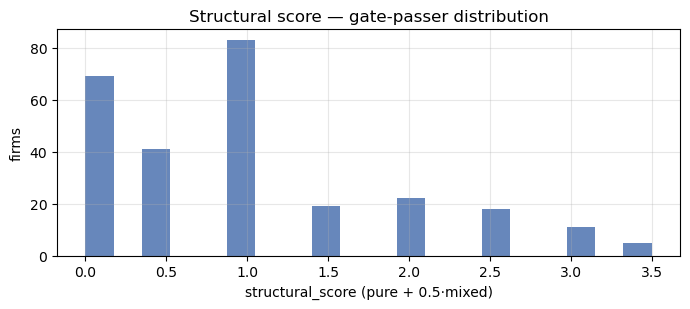

[struct] country × mean structural_score (top 15):
     mean  count
fic             
NZ   3.00      1
TR   2.00      3
TH   2.00      6
KW   2.00      2
ZA   1.75      8
MY   1.62      8
SA   1.50      7
PH   1.50      2
IN   1.46     26
TW   1.32     28
IE   1.00      1
PL   1.00      1
NL   1.00      2
MX   1.00      6
JP   0.96     49 

[struct] GICS sector × mean structural_score:
           mean  count
gsector_s             
10         1.38      4
55         1.29      7
25         1.16     38
30         1.12     32
45         1.06     49
15         1.04     24
35         1.03     30
20         0.84     64
50         0.78     20 

[struct] top 10 by structural_score alone (composite-independent):
              company_name fic gsector  structural_score  structural_score_pure  structural_score_mixed structural_tags  composite  final_score
       ASIA OPTICAL CO INC  TW      45               3.5                      3                       1 BMK|COV|STY|RTL      0.730        1.241
  

In [23]:
# ── 11b.1 · Structural score distribution across gate-passers ──────────
print(f"[struct] gate-passers scored: {len(m):,}")
print("[struct] structural_score distribution (pure + 0.5·mixed):")
print(m["structural_score"].describe().round(2).to_string(), "\n")

_bucket_edges = [-0.01, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.5]
_bucket_labels = ["0", "0<s≤1", "1<s≤2", "2<s≤3", "3<s≤4", "4<s≤5", "5+"]
_buckets = pd.cut(m["structural_score"], _bucket_edges, labels=_bucket_labels)
print("[struct] bucket counts:")
print(_buckets.value_counts().sort_index().to_string(), "\n")

try:
    fig, ax = plt.subplots(figsize=(7, 3.2))
    m["structural_score"].hist(bins=20, ax=ax, color="#4c72b0", alpha=0.85)
    ax.set_title("Structural score — gate-passer distribution")
    ax.set_xlabel("structural_score (pure + 0.5·mixed)")
    ax.set_ylabel("firms")
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
except Exception as _e:
    print(f"[struct] histogram skipped: {_e}")

# ── 11b.2 · Country × mean structural score ────────────────────────────
_by_country = (m.groupby("fic")["structural_score"]
                .agg(["mean", "count"])
                .sort_values("mean", ascending=False)
                .round(2))
print("[struct] country × mean structural_score (top 15):")
print(_by_country.head(15).to_string(), "\n")

# ── 11b.3 · Sector × mean structural score ─────────────────────────────
_by_sector = (m.assign(gsector_s=m["gsector"].astype(str))
                .groupby("gsector_s")["structural_score"]
                .agg(["mean", "count"])
                .sort_values("mean", ascending=False)
                .round(2))
print("[struct] GICS sector × mean structural_score:")
print(_by_sector.to_string(), "\n")

# ── 11b.4 · Top 10 gate-passers by structural_score alone ──────────────
_top_struct_cols = ["company_name","fic","gsector","structural_score",
                    "structural_score_pure","structural_score_mixed",
                    "structural_tags","composite","final_score"]
_top_struct = (m.nlargest(10, "structural_score")[_top_struct_cols]
                 .copy()
                 .round({"structural_score":2, "composite":3, "final_score":3}))
print("[struct] top 10 by structural_score alone (composite-independent):")
print(_top_struct.to_string(index=False), "\n")

# ── 11b.5 · Per-name interpretation for the final 20 ───────────────────
tag_interpretations = {
    "tag_esg_excluded":     "excluded from ESG-constrained mandates",
    "tag_benchmark_orphan": "sits outside core benchmark bands → passive under-weight",
    "tag_low_coverage":     "thin sell-side coverage (mcap proxy)",
    "tag_complexity":       "conglomerate / holding / dual-class structure",
    "tag_style_orphan":     "middle-of-the-road style — neither deep-value nor growth",
    "tag_orphan_country":   "domiciled in an orphan market with limited FDI",
    "tag_retail_dominated": "retail-dominated ownership → institutional under-allocation",
}
_tag_cols = list(tag_interpretations.keys())

print("[struct] per-name interpretation — final 20:")
for _, row in selected.iterrows():
    name = str(row.get("company_name", ""))[:28]
    fic = row.get("fic", "")
    sec = str(row.get("gsector", ""))
    s_pure = int(row.get("structural_score_pure", 0))
    s_mix  = int(row.get("structural_score_mixed", 0))
    s_tot  = float(row.get("structural_score", 0.0))
    smul   = float(row.get("structural_multiplier", 1.0))
    comp   = float(row.get("composite", 0.0))
    fin    = float(row.get("final_score", 0.0))
    hit = [tag_interpretations[c] for c in _tag_cols if int(row.get(c, 0)) == 1]
    hdr = f"  {name:<28} {fic:<3} GICS{sec:<3} | pure={s_pure} mix={s_mix} s={s_tot:.1f} × {smul:.2f} → fin={fin:.3f} (comp={comp:.3f})"
    print(hdr)
    if hit:
        for t in hit:
            print(f"      • {t}")
    else:
        print("      • no structural tags — selected on composite alone")


## 12 · Visualisations

saved → /Users/conradgreen/Documents/SIA_Portfolio/data/outputs/01_screen_diagnostics.png


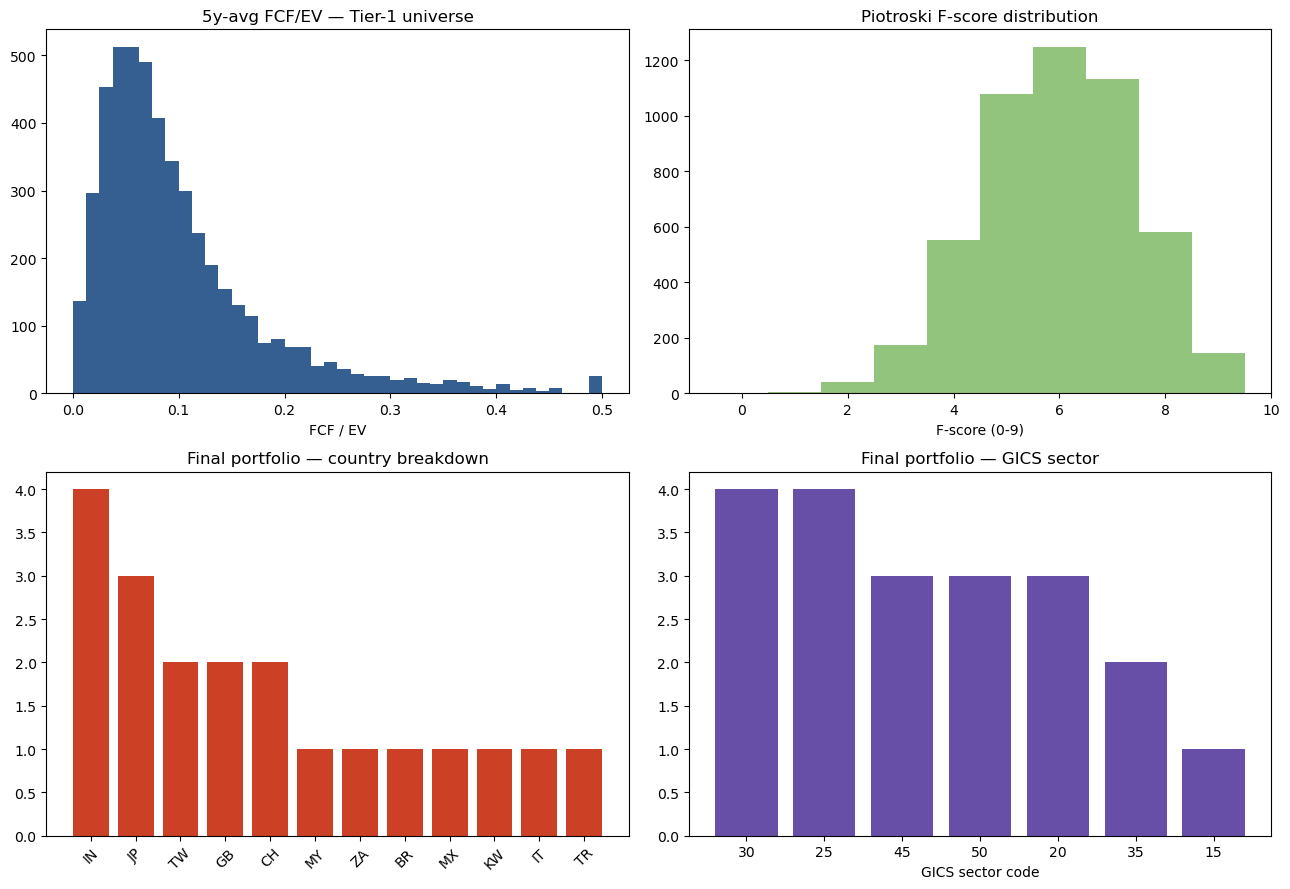

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].hist(metrics["fcf_ev_5y_avg"].clip(-0.2, 0.5), bins=40, color="#365f91")
axes[0, 0].set_title("5y-avg FCF/EV — Tier-1 universe")
axes[0, 0].set_xlabel("FCF / EV")

axes[0, 1].hist(metrics["piotroski"], bins=range(0, 11), color="#93c47d", align="left")
axes[0, 1].set_title("Piotroski F-score distribution")
axes[0, 1].set_xlabel("F-score (0-9)")

cc = selected["fic"].value_counts()
axes[1, 0].bar(cc.index, cc.values, color="#cc4125")
axes[1, 0].set_title("Final portfolio — country breakdown")
axes[1, 0].tick_params(axis="x", rotation=45)

sc = selected["gsector"].astype(str).value_counts()
axes[1, 1].bar(sc.index, sc.values, color="#674ea7")
axes[1, 1].set_title("Final portfolio — GICS sector")
axes[1, 1].set_xlabel("GICS sector code")

plt.tight_layout()
out = OUT / "01_screen_diagnostics.png"
plt.savefig(out, dpi=160, bbox_inches="tight")
print(f"saved \u2192 {out}")
plt.show()

## 12b · Top-10 ex-US deep-dive: key metrics + 1-year price charts

For the ten highest-ranked names in the ex-US pool we plot:
- **Radar chart** of normalised screen metrics (Piotroski, 5y ROIC, 5y FCF growth, 5y FCF/EV, composite).
- **Bar chart** comparing the raw metric values side by side.
- **1-year daily price chart** (sourced from Yahoo Finance via `yfinance`).

Note: `TICKER_MAP` may need refreshing after re-running the screen — names without a mapping render as "no data".

In [25]:
import yfinance as yf
from matplotlib.lines import Line2D

# ── Ticker map — aligned with current top-10 after screen re-run ──
# Companies without Yahoo Finance coverage are mapped to None
# and will show "no ticker mapped" on the price chart.
TICKER_MAP = {
    "CENTRUM NOWOCZESNYCH TECH SA":  None,           # WSE micro-cap, no YF data
    "SERVOCA PLC":                   None,           # AIM micro-cap, no YF data
    "SEO HEE CONSTR CO LTD":        "035890.KQ",
    "TIGERS POLYMER CORP":          "4231.T",
    "SONDOTECNICA ENGENHARIA":      "SOND3.SA",
    "NIKKEN KOGAKU CO LTD":         "7722.T",
    "COSCO CAPITAL INC":            None,           # PSE, no YF data
    "MERAFE RESOURCES LTD":         "MRF.JO",
    "LANNA RESOURCES PUBLIC CO":    "LANNA.BK",
    "PARKSON RETAIL ASIA LTD":      None,           # SGX, delisted / no YF data
}

top10 = selected_view.head(10).copy()
top10["ticker"]     = top10["company_name"].map(TICKER_MAP)
top10["short_name"] = top10["company_name"].str[:18]
print(top10[["company_name", "ticker"]].to_string(index=False))

                company_name ticker
         ASIA OPTICAL CO INC    NaN
  CARLSBERG BREWERY MALAYSIA    NaN
                  USS CO LTD    NaN
            SANOFI INDIA LTD    NaN
            CLICKS GROUP LTD    NaN
               ODONTOPREV SA    NaN
                    NEXT PLC    NaN
   LOGITECH INTERNATIONAL SA    NaN
      GRUPO HERDEZ SAB DE CV    NaN
THE BOMBAY BURMAH TRADING CO    NaN


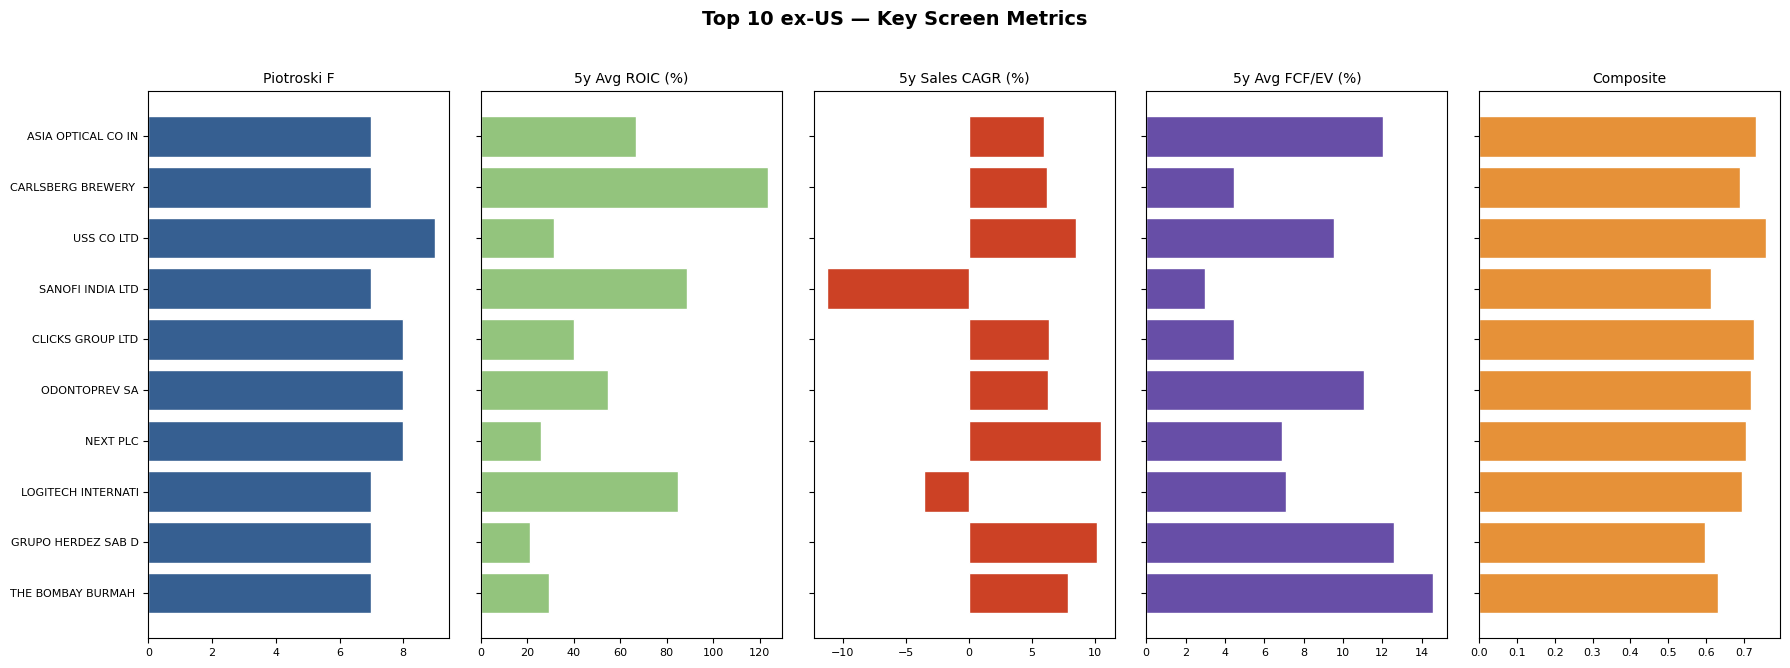

In [26]:
# ── 1) Bar charts: key metrics side-by-side ──────────────────────
metric_cols = {
    "piotroski":      "Piotroski F",
    "roic_5y_avg":    "5y Avg ROIC",
    "sales_growth_5y": "5y Sales CAGR",
    "fcf_ev_5y_avg":  "5y Avg FCF/EV",
    "composite":      "Composite",
}
palette = ["#365f91", "#93c47d", "#cc4125", "#674ea7", "#e69138"]

fig, axes = plt.subplots(1, len(metric_cols), figsize=(18, 6.5), sharey=False)
fig.suptitle("Top 10 ex-US — Key Screen Metrics", fontsize=14, fontweight="bold", y=1.02)
for i, (col, label) in enumerate(metric_cols.items()):
    ax = axes[i]
    vals = top10[col].astype(float)
    if col in ("roic_5y_avg", "sales_growth_5y", "fcf_ev_5y_avg"):
        vals = vals * 100
        label += " (%)"
    ax.barh(top10["short_name"], vals, color=palette[i], edgecolor="white")
    ax.set_title(label, fontsize=10)
    ax.invert_yaxis()
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=8)
    if i > 0:
        ax.set_yticklabels([])
plt.tight_layout()
plt.savefig(OUT / "12b_top10_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

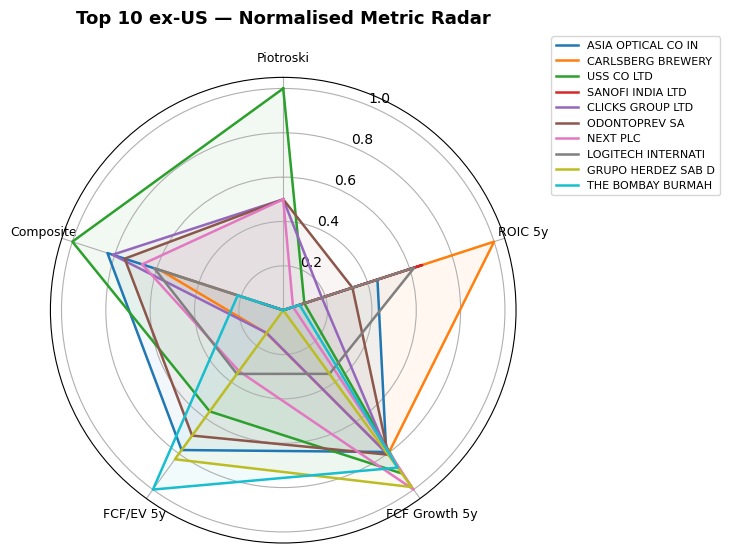

In [27]:
# ── 2) Radar chart: normalised metrics across the top 10 ──────────
from math import pi as PI

radar_cols   = ["piotroski", "roic_5y_avg", "sales_growth_5y", "fcf_ev_5y_avg", "composite"]
radar_labels = ["Piotroski", "ROIC 5y", "FCF Growth 5y", "FCF/EV 5y", "Composite"]

normed = top10[radar_cols].apply(lambda c: (c - c.min()) / (c.max() - c.min() + 1e-9))
N = len(radar_cols)
angles = [n / float(N) * 2 * PI for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(PI / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=9)

cmap = plt.cm.tab10
for idx, (_, row) in enumerate(normed.iterrows()):
    vals = row[radar_cols].tolist() + [row[radar_cols[0]]]
    name = top10["short_name"].iloc[idx]
    ax.plot(angles, vals, linewidth=1.8, label=name, color=cmap(idx % 10))
    ax.fill(angles, vals, alpha=0.06, color=cmap(idx % 10))

ax.set_title("Top 10 ex-US — Normalised Metric Radar", fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.45, 1.1), fontsize=8)
plt.tight_layout()
plt.savefig(OUT / "12b_top10_radar.png", dpi=160, bbox_inches="tight")
plt.show()

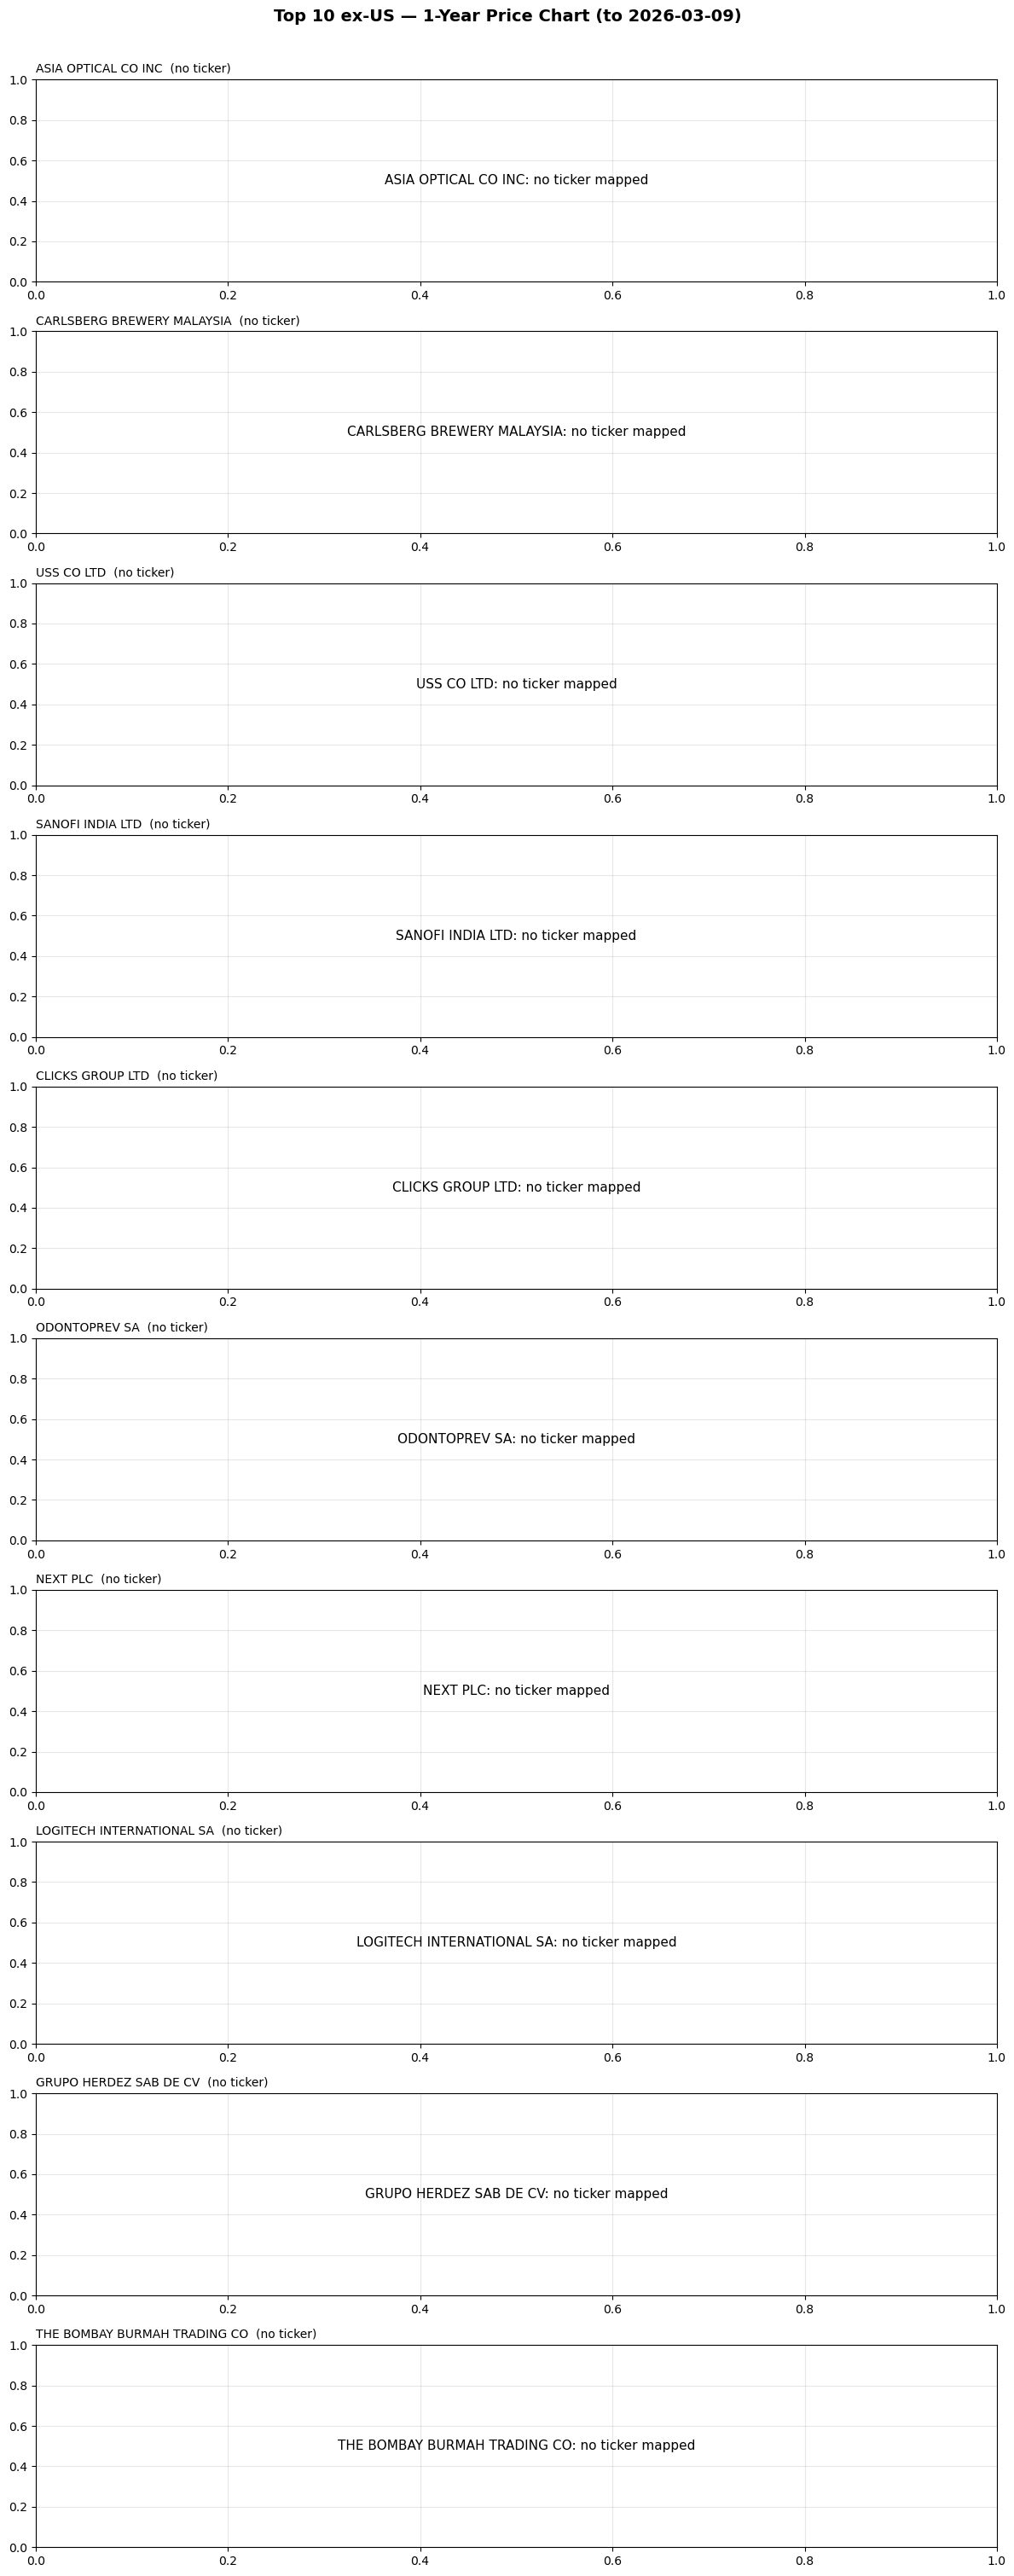

✓ Top-10 visuals saved to data/outputs/


In [28]:
# ── 3) 1-year price charts (Yahoo Finance) ───────────────────────
price_end   = pd.Timestamp(SCREEN_ASOF)
price_start = price_end - pd.DateOffset(years=1)

fig, axes = plt.subplots(len(top10), 1, figsize=(12, 3 * len(top10)), sharex=False)
if len(top10) == 1:
    axes = [axes]
fig.suptitle(f"Top 10 ex-US — 1-Year Price Chart (to {SCREEN_ASOF})",
             fontsize=14, fontweight="bold", y=1.005)

for i, (_, row) in enumerate(top10.iterrows()):
    ax = axes[i]
    tick = row["ticker"]
    name = row["company_name"]
    if not isinstance(tick, str) or not tick:
        ax.text(0.5, 0.5, f"{name}: no ticker mapped", transform=ax.transAxes,
                ha="center", va="center", fontsize=11)
    else:
        try:
            hist = yf.Ticker(tick).history(
                start=price_start.strftime("%Y-%m-%d"),
                end=price_end.strftime("%Y-%m-%d"),
            )
            if hist.empty:
                ax.text(0.5, 0.5, f"{tick}: no data", transform=ax.transAxes,
                        ha="center", va="center", fontsize=12)
            else:
                ax.plot(hist.index, hist["Close"], color=palette[i % len(palette)], linewidth=1.5)
                ax.fill_between(hist.index, hist["Close"], alpha=0.15, color=palette[i % len(palette)])
                first, last = hist["Close"].iloc[0], hist["Close"].iloc[-1]
                ret = (last / first - 1) * 100
                ccy = hist.attrs.get("currency", "")
                ax.set_ylabel(f"Price ({ccy})" if ccy else "Price", fontsize=9)
                ax.annotate(f"1y return: {ret:+.1f}%", xy=(0.98, 0.92),
                            xycoords="axes fraction", ha="right", fontsize=9,
                            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
        except Exception as e:
            ax.text(0.5, 0.5, f"{tick}: {e}", transform=ax.transAxes,
                    ha="center", va="center", fontsize=10)
    ax.set_title(f"{name}  ({tick if isinstance(tick, str) else 'no ticker'})", fontsize=10, loc="left")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / "12b_top10_price_1y.png", dpi=160, bbox_inches="tight")
plt.show()
print("✓ Top-10 visuals saved to data/outputs/")

## 13 · Persist outputs

In [29]:
selected_view.to_csv(OUT / "portfolio_screen_final20.csv", index=False)
metrics.to_parquet(OUT / "tier1_firm_metrics.parquet", index=False)
panel5.to_parquet(OUT / "tier1_panel5y.parquet", index=False)

provenance = pd.DataFrame({
    "key":   ["asof", "run_timestamp", "n_universe_firms", "n_tier1_survivors", "n_selected"],
    "value": [str(SCREEN_ASOF), stamp(), company['gvkey'].nunique(),
              metrics['gvkey'].nunique(), len(selected)],
})
provenance.to_csv(OUT / "run_provenance.csv", index=False)
print(provenance.to_string(index=False))

              key                     value
             asof                2026-03-09
    run_timestamp 2026-04-16T19:48:51+00:00
 n_universe_firms                     60637
n_tier1_survivors                      4957
       n_selected                        20


## 14 · Data-sanity spot-check

Pulls the latest-FY raw Compustat Global values for a small set of marquee
firms (incl. NEXT PLC) so you can eyeball them against each company's
annual report or Yahoo Finance in ~60s. A distribution-sanity table of
key ratios across gate-passers follows — any absurd 1% / 99% tail
indicates a unit, currency, or calculation issue.

**Fundamentals are in MILLIONS of local currency** (per `curcd`);
`mcap_loc_bn` and `mcap_usd_bn` are in BILLIONS.


In [30]:
from tabulate import tabulate

# Marquee firms — name fragments (case-insensitive substring match on company_name)
SPOT_NAMES = [
    "NESTLE",
    "TOYOTA MOTOR",
    "LVMH",
    "SAP SE",
    "SAMSUNG ELECTRONIC",
    "AIA GROUP",
    "NEXT PLC",
]

spot_gvkeys, resolved = [], []
for q in SPOT_NAMES:
    cand = company[company["company_name"].str.contains(q, case=False, na=False, regex=False)]
    if len(cand) == 0:
        # Second-chance: drop common suffixes
        simpler = q.replace(" PLC", "").replace(" SE", "").replace(" GROUP", "").strip()
        cand = company[company["company_name"].str.contains(simpler, case=False, na=False, regex=False)]
    if len(cand) == 0:
        print(f"  [miss]  {q:<22s} — no match in company table")
        continue
    # Take top 1–2 matches (to catch ADR + ordinary listings)
    for _, r in cand.head(2).iterrows():
        spot_gvkeys.append(r["gvkey"])
        resolved.append((q, r["gvkey"], r["company_name"], r["fic"]))
        print(f"  [hit]   {q:<22s} -> gvkey={r['gvkey']} {r['company_name']} ({r['fic']})")

# Latest FY row per matched firm (from cleaned `funda`, post-filing-lag filter)
spot = (funda.sort_values("datadate")
              .groupby("gvkey").tail(1)
              .loc[lambda d: d["gvkey"].isin(spot_gvkeys)]
              .merge(company[["gvkey","company_name"]], on="gvkey", how="left"))
spot = spot.merge(
    latest_mcap[["gvkey","market_cap_local","market_cap_usd","price_asof","asof_price_date"]],
    on="gvkey", how="left",
)
spot["fcf"] = pd.to_numeric(spot["oancf"], errors="coerce") - pd.to_numeric(spot["capx"], errors="coerce")

# Pretty display
disp = spot[[
    "company_name","fic","curcd","fyear","datadate",
    "sale","oibdp","ebit","ni","oancf","capx","fcf","dp",
    "at","dltt","che","csho",
    "price_asof","market_cap_local","market_cap_usd",
]].copy()
for c in ["sale","oibdp","ebit","ni","oancf","capx","fcf","dp","at","dltt","che"]:
    disp[c] = pd.to_numeric(disp[c], errors="coerce").round(0)
disp["csho"]        = pd.to_numeric(disp["csho"],        errors="coerce").round(1)
disp["price_asof"]  = pd.to_numeric(disp["price_asof"],  errors="coerce").round(2)
disp["datadate"]    = pd.to_datetime(disp["datadate"]).dt.date
disp["mcap_loc_bn"] = (pd.to_numeric(disp["market_cap_local"], errors="coerce") / 1e9).round(2)
disp["mcap_usd_bn"] = (pd.to_numeric(disp["market_cap_usd"],   errors="coerce") / 1e9).round(2)
disp = disp.drop(columns=["market_cap_local","market_cap_usd"])

print(f"\n=== SPOT-CHECK — latest-FY raw values (n={len(disp)}) ===")
print("Compare each row to the firm's annual report (IR website or Yahoo Finance).")
print("Green light: sale / ni / fcf match within ~1–2% and curcd looks right.\n")
print(tabulate(disp, headers="keys", tablefmt="simple", showindex=False))

# Freshness: any of these firms with a stale latest datadate?
stale = disp[(pd.to_datetime(SCREEN_ASOF) - pd.to_datetime(disp["datadate"])).dt.days > 540]
if len(stale):
    print(f"\n[warn] {len(stale)} spot-check firm(s) have latest datadate > 18m old — reporting lag:")
    print(stale[["company_name","fic","datadate"]].to_string(index=False))

# ── Distribution sanity across all gate-passers (m DataFrame) ──────────
print("\n=== DISTRIBUTION SANITY — 1% / 50% / 99% quantiles across gate-passers ===")
sanity_cols = ["roic_5y_avg","fcf_margin_5y_avg","fcf_ev_5y_avg","maint_fcf_ev_5y_avg",
               "net_debt_ebitda","pe_ratio","earnings_yield","piotroski","altman_z"]
present = [c for c in sanity_cols if c in m.columns]
q = m[present].quantile([0.01, 0.50, 0.99]).round(3)
q.index = ["1%", "50%", "99%"]
print(q.T.to_string())
print("\nExpected sensible ranges (99% tail): roic < 1.0, fcf_margin < 0.5, pe_ratio < 100, "
      "altman_z < 20, |net_debt_ebitda| < 15. Anything obviously off points at a unit/currency bug.")


  [hit]   NESTLE                 -> gvkey=016603 NESTLE SA/AG (CHE)
  [hit]   NESTLE                 -> gvkey=103756 NESTLE (MALAYSIA) BHD (MYS)
  [hit]   TOYOTA MOTOR           -> gvkey=019661 TOYOTA MOTOR CORP (JPN)
  [hit]   TOYOTA MOTOR           -> gvkey=209119 TOKYO TOYOTA MOTOR CO (JPN)
  [hit]   LVMH                   -> gvkey=014447 LVMH MOET HENNESSY LOUIS V (FRA)
  [hit]   SAP SE                 -> gvkey=103487 SAP SE (DEU)
  [hit]   SAMSUNG ELECTRONIC     -> gvkey=104604 SAMSUNG ELECTRONICS CO LTD (KOR)
  [hit]   SAMSUNG ELECTRONIC     -> gvkey=367204 CSOP SAMSUNG ELECTRONICS DAI (HKG)
  [hit]   AIA GROUP              -> gvkey=101457 SAIAG SPA (ITA)
  [hit]   AIA GROUP              -> gvkey=203815 TAIAN ELECTRIC (TWN)
  [hit]   NEXT PLC               -> gvkey=100149 NEXT PLC (GBR)

=== SPOT-CHECK — latest-FY raw values (n=7) ===
Compare each row to the firm's annual report (IR website or Yahoo Finance).
Green light: sale / ni / fcf match within ~1–2% and curcd looks right.


In [ ]:
# ── ROIC pipeline trace — Hong Leong Industries (MY) ──────────────────
# Step through every intermediate value to find the calculation error.
from tabulate import tabulate

_q = "HONG LEONG IND"
_hl = company[company["company_name"].str.contains(_q, case=False, na=False)]
if _hl.empty:
    _hl = company[company["company_name"].str.contains("HONG LEONG", case=False, na=False)]
print(f"company table matches for \"{_q}\":")
print(_hl[["gvkey","company_name","fic","gsector","gsubind"]].to_string(index=False), "\n")

if not _hl.empty:
    _gv = _hl.iloc[0]["gvkey"]
    _name = _hl.iloc[0]["company_name"]
    print(f"Tracing gvkey={_gv} ({_name})\n")

    # 1) Raw funda rows for this firm
    _rows = funda[funda["gvkey"] == _gv].sort_values("datadate").copy()
    _raw_cols = ["fyear","datadate","curcd","sale","oibdp","ebit","ni","oancf","capx",
                 "dp","txt","pi","at","dlc","dltt","ceq","che","lt","csho","xint","dvt","re"]
    _present = [c for c in _raw_cols if c in _rows.columns]
    print(f"=== RAW funda rows ({len(_rows)} FYs) ===")
    print(tabulate(_rows[_present].round(1), headers="keys", tablefmt="simple", showindex=False))

    # 2) Derived ROIC components — reproduce cell 17 logic
    print(f"\n=== ROIC decomposition (per FY) ===")
    _trace = _rows[["fyear","curcd"]].copy()
    _trace["ebit"]     = pd.to_numeric(_rows["ebit"], errors="coerce")
    _trace["txt"]      = pd.to_numeric(_rows["txt"],  errors="coerce")
    _trace["pi"]       = pd.to_numeric(_rows["pi"],   errors="coerce")
    _trace["tax_rate"] = (_trace["txt"] / _trace["pi"]).clip(0, 0.5).fillna(0.25)
    _trace["nopat"]    = _trace["ebit"] * (1 - _trace["tax_rate"])
    _trace["dlc"]      = pd.to_numeric(_rows["dlc"],  errors="coerce").fillna(0)
    _trace["dltt"]     = pd.to_numeric(_rows["dltt"], errors="coerce").fillna(0)
    _trace["ceq"]      = pd.to_numeric(_rows["ceq"],  errors="coerce").fillna(0)
    _trace["che"]      = pd.to_numeric(_rows["che"],  errors="coerce").fillna(0)
    _trace["invested_raw"] = _trace["dlc"] + _trace["dltt"] + _trace["ceq"] - _trace["che"]
    _at = pd.to_numeric(_rows["at"], errors="coerce").values
    _trace["invested"] = _trace["invested_raw"].clip(lower=0.20 * _at)
    _trace["roic"]     = (_trace["nopat"] / _trace["invested"].where(_trace["invested"] > 0)).clip(upper=1.0)

    _show = ["fyear","curcd","ebit","txt","pi","tax_rate","nopat",
             "dlc","dltt","ceq","che","invested_raw","invested","roic"]
    print(tabulate(_trace[_show].round(3), headers="keys", tablefmt="simple", showindex=False))

    # 3) Flag anomalies
    print(f"\n=== Anomaly checks ===")
    _low_inv = _trace[_trace["invested"] < _trace["nopat"] * 0.5]
    if not _low_inv.empty:
        print(f"⚠ INVESTED CAPITAL < 0.5×NOPAT in {len(_low_inv)} FY(s) → ROIC artificially inflated:")
        print(f"  FYs: {_low_inv['fyear'].tolist()}")

    _neg_inv = _trace[_trace["invested"] <= 0]
    if not _neg_inv.empty:
        print(f"⚠ INVESTED CAPITAL ≤ 0 in {len(_neg_inv)} FY(s) → ROIC = NaN:")
        print(f"  FYs: {_neg_inv['fyear'].tolist()}")

    _tax_odd = _trace[(_trace["tax_rate"] < 0.05) | (_trace["tax_rate"] >= 0.49)]
    if not _tax_odd.empty:
        print(f"⚠ Tax rate outside [5%,49%] in {len(_tax_odd)} FY(s) — check pi vs txt:")
        for _, r in _tax_odd.iterrows():
            print(f"  FY{int(r['fyear'])}: txt={r['txt']:.1f}  pi={r['pi']:.1f}  rate={r['tax_rate']:.3f}")

    _pi_ebit = _trace[(_trace["pi"].abs() > 2 * _trace["ebit"].abs()) & (_trace["ebit"] > 0)]
    if not _pi_ebit.empty:
        print(f"⚠ |pi| > 2×|ebit| in {len(_pi_ebit)} FY(s) — likely equity-method / investment income inflating pi:")
        for _, r in _pi_ebit.iterrows():
            print(f"  FY{int(r['fyear'])}: ebit={r['ebit']:.1f}  pi={r['pi']:.1f}  ratio={r['pi']/r['ebit']:.2f}x")

    # 4) 5y avg ROIC (same as cell 24)
    _last5 = _trace.tail(5)["roic"]
    _roic5 = _last5.mean()
    print(f"\n5y avg ROIC = {_roic5:.4f}  ({_roic5*100:.1f}%)")
    print(f"  per-year: {[round(float(x),4) for x in _last5.values]}")

    # 5) What the screen shows
    if _gv in m["gvkey"].values:
        _mrow = m[m["gvkey"] == _gv].iloc[0]
        print(f"\nScreen values for this firm:")
        for c in ["roic_5y_avg","roic_min_10y","fcf_margin_5y_avg","piotroski",
                   "fcf_ev_5y_avg","maint_fcf_ev_5y_avg","earnings_yield","net_debt_ebitda",
                   "altman_z","composite","final_score","rank_final"]:
            if c in _mrow.index:
                v = _mrow[c]
                print(f"  {c:28s} = {v}")
    else:
        print(f"\n{_name} not found in gate-passer set `m` — may have been filtered.")

# ── Broader ROIC sanity: firms with suspiciously high ROIC ────────────
print("\n=== ROIC sanity — gate-passers with ROIC 5y avg > 50% ===")
_sus = m[m["roic_5y_avg"] > 0.50][["company_name","fic","roic_5y_avg","roic_min_10y",
        "composite","rank_final"]].sort_values("roic_5y_avg", ascending=False).head(15)
if _sus.empty:
    print("None found.")
else:
    _sus["roic_5y_avg"]  = (_sus["roic_5y_avg"]*100).round(1)
    _sus["roic_min_10y"] = (_sus["roic_min_10y"]*100).round(1)
    print(tabulate(_sus, headers="keys", tablefmt="simple", showindex=False))
    print("(any of these with tiny invested capital may have inflated ROIC — check ceq vs che)")


In [ ]:
from tabulate import tabulate

# ── Verification sheet: FY2025 core metrics for every selected name ────
# Pulls the LATEST fiscal year's raw ROIC and FCF yield alongside mcap
# so you can cross-check against annual reports or Yahoo Finance.

# User's final portfolio — 22 names from fundamental analysis
_FINAL_NAMES = [
    "CLICKS GROUP",
    "ODONTOPREV",
    "LARGAN PRECISION",
    "NEXT PLC",
    "GAMES WORKSHOP",
    "AUTOTRADER GROUP",
    "CROMPTON GREAVES CONSUMER",
    "KAKAKU.COM",
    "RECRUIT HOLDINGS",
    "TECHNOGYM",
    "HANJAYA MANDALA SAMPOERNA",
    "DORMAKABA HOLD",
    "ROCHE HOLD",
    "ITC LTD",
    "MARUWA CO",
    "RATIONAL AG",
    "BUMRUNGRAD",
    "MR PRICE GROUP",
    "KING SLIDE WORKS",
    "KIMBERLY-CLARK DE MEXICO",
    "SAUDI DAIRY",   # SADAFCO
    "PETRONET LNG",
]

# Match each name against gate-passers (m) by substring
_matched_gvkeys = []
_missed = []
for q in _FINAL_NAMES:
    cand = m[m["company_name"].str.contains(q, case=False, na=False, regex=False)]
    if cand.empty:
        # Try shorter fragment
        short = q.split()[0] + " " + q.split()[1] if len(q.split()) > 1 else q
        cand = m[m["company_name"].str.contains(short, case=False, na=False, regex=False)]
    if cand.empty:
        cand = m[m["company_name"].str.contains(q.split()[0], case=False, na=False, regex=False)]
    if not cand.empty:
        _matched_gvkeys.append(cand.iloc[0]["gvkey"])
        print(f"  [hit]  {q:<30s} -> {cand.iloc[0]['company_name']} ({cand.iloc[0]['fic']})")
    else:
        _missed.append(q)
        print(f"  [miss] {q:<30s} — not found in gate-passer set")

if _missed:
    print(f"\n\u26a0 {len(_missed)} name(s) not matched in gate-passers \u2014 tracing pipeline:")
    for q in _missed:
        frags = [q] + q.split() + [q[:8]]
        cand = pd.DataFrame()
        for frag in frags:
            if len(frag) < 3: continue
            cand = company[company["company_name"].str.contains(frag, case=False, na=False, regex=False)]
            if not cand.empty: break
        if cand.empty:
            print(f"  {q} \u2014 not found in Compustat Global at all")
            continue
        for _, r in cand.head(2).iterrows():
            gv = r["gvkey"]
            cname = r["company_name"]
            cfic = r["fic"]
            print(f"\n  {q} -> {cname} ({cfic}) gvkey={gv}")
            in_funda = gv in funda["gvkey"].values
            n_fy = int(funda[funda["gvkey"]==gv]["fyear"].nunique()) if in_funda else 0
            in_metrics = gv in metrics["gvkey"].values
            in_m = gv in m["gvkey"].values
            print(f"    in funda:    {'YES' if in_funda else 'NO'} ({n_fy} fiscal years)")
            print(f"    in metrics:  {'YES' if in_metrics else 'NO'}")
            print(f"    in gates(m): {'YES' if in_m else 'NO'}")
            if in_funda and not in_metrics:
                print("    dropped before gates: likely <5 FYs or missing core metrics")
            if in_metrics and not in_m:
                mr = metrics[metrics["gvkey"]==gv].iloc[0]
                fic_raw = mr.get("fic","")
                fic2 = {v:k for k,v in ISO2_TO_ISO3.items()}.get(fic_raw, fic_raw)
                mcap_v = pd.to_numeric(mr.get("market_cap_usd",0), errors="coerce")
                p10g = panel.sort_values(["gvkey","fyear"]).groupby("gvkey").tail(10)
                gv_p10 = p10g[p10g["gvkey"]==gv]
                n10 = int(gv_p10["fyear"].nunique())
                fpos = int((gv_p10["fcf"]>0).sum()) if n10>0 else 0
                print("    failed a gate. Diagnostic:")
                print(f"      country={fic_raw} (ISO2={fic2}), in UNIVERSE: {fic2 in UNIVERSE}")
                print(f"      mcap_usd={mcap_v:,.0f}")
                print(f"      10y FYs={n10} (need 10)")
                print(f"      FCF>0 years={fpos}/10 (need 6)")
                checks = [
                    ("roic_5y_avg", "ROIC 5y avg", ROIC_5Y_MIN),
                    ("fcf_margin_5y_avg", "FCF margin 5y", FCF_MARGIN_5Y_MIN),
                    ("piotroski", "Piotroski", PIOTROSKI_MIN),
                ]
                for col, label, thresh in checks:
                    val = mr.get(col, np.nan)
                    ok = bool(val >= thresh) if pd.notna(val) else False
                    tag = "pass" if ok else "FAIL"
                    print(f"      {label}: {val} (>={thresh}) [{tag}]")

_ver = m[m["gvkey"].isin(_matched_gvkeys)].copy()
print(f"\nMatched {len(_ver)} of {len(_FINAL_NAMES)} names")

# Latest-FY ROIC (already computed per-year in panel, grab the latest)
_latest_panel = (panel.sort_values("datadate")
                      .groupby("gvkey").tail(1)
                      .set_index("gvkey")[["fyear","datadate","curcd","sale","ebit",
                                           "oancf","capx","dp","ni","txt","pi",
                                           "dlc","dltt","ceq","che","at"]])
_ver = _ver.merge(_latest_panel, on="gvkey", how="left")

# Recompute current-FY ROIC (same formula as cell 17 with floor + cap)
_tax = (pd.to_numeric(_ver["txt"], errors="coerce") /
        pd.to_numeric(_ver["pi"],  errors="coerce")).clip(0, 0.5).fillna(0.25)
_nopat = pd.to_numeric(_ver["ebit"], errors="coerce") * (1 - _tax)
_inv = (pd.to_numeric(_ver["dlc"], errors="coerce").fillna(0)
      + pd.to_numeric(_ver["dltt"], errors="coerce").fillna(0)
      + pd.to_numeric(_ver["ceq"], errors="coerce").fillna(0)
      - pd.to_numeric(_ver["che"], errors="coerce").fillna(0))
_at = pd.to_numeric(_ver["at"], errors="coerce")
_inv = _inv.clip(lower=0.20 * _at)
_ver["current_roic"] = (_nopat / _inv.where(_inv > 0)).clip(upper=1.0)

# Current-FY FCF
_ver["current_fcf"] = (pd.to_numeric(_ver["oancf"], errors="coerce")
                     - pd.to_numeric(_ver["capx"],  errors="coerce"))

# FCF yield = current FCF / market_cap (both need same units)
# FCF is in millions of local currency; market_cap_local is in raw units.
# Divide market_cap_local by 1e6 to match.
_mcap_m = pd.to_numeric(_ver["market_cap_local"], errors="coerce") / 1e6
_ver["current_fcf_yield"] = _ver["current_fcf"] / _mcap_m.where(_mcap_m > 0)

# Maintenance-FCF yield (owner earnings)
_dp = pd.to_numeric(_ver["dp"], errors="coerce")
_capx = pd.to_numeric(_ver["capx"], errors="coerce")
_maint_fcf = pd.to_numeric(_ver["oancf"], errors="coerce") - np.where(
    _dp.notna(), np.maximum(_dp.fillna(0), _capx.fillna(0) * 0.5), _capx.fillna(0))
_ver["current_maint_fcf_yield"] = _maint_fcf / _mcap_m.where(_mcap_m > 0)

# Pretty display
disp = pd.DataFrame({
    "Company":      _ver["company_name"].values,
    "Country":      _ver["fic"].values,
    "Sector":       _ver["gsector"].astype(str).values,
    "FY":           _ver["fyear"].astype(int).values,
    "Currency":     _ver["curcd"].values,
    "Revenue(m)":   pd.to_numeric(_ver["sale"], errors="coerce").round(0).values,
    "EBIT(m)":      pd.to_numeric(_ver["ebit"], errors="coerce").round(0).values,
    "NI(m)":        pd.to_numeric(_ver["ni"], errors="coerce").round(0).values,
    "FCF(m)":       _ver["current_fcf"].round(0).values,
    "ROIC%":        (_ver["current_roic"] * 100).round(1).values,
    "ROIC_5y%":     (_ver["roic_5y_avg"] * 100).round(1).values,
    "FCFyld%":      (_ver["current_fcf_yield"] * 100).round(2).values,
    "EY%":          (_ver["earnings_yield"] * 100).round(2).values,
    "Mcap($m)":     (_ver["market_cap_usd"] / 1e6).round(0).astype(int).values,
    "PE":           _ver["pe_ratio"].round(1).values,
}).sort_values("ROIC%", ascending=False).reset_index(drop=True)
disp.insert(0, "#", range(1, len(disp)+1))

print(f"=== SELECTED PORTFOLIO — {len(disp)} names | latest-FY core metrics for verification ===")
print(f"ROIC% = current-FY ROIC (floored at 20% AT, capped 100%) | ROIC_5y% = 5y avg")
print(f"FCFyld% = current FCF / mcap | EY% = NI / mcap | Mcap($m) = USD millions")
print(f"Revenue/EBIT/NI/FCF in millions of local currency (see Currency col)\n")
print(tabulate(disp, headers="keys", tablefmt="simple", showindex=False))
